In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load business data (this file is small enough to load entirely)
business = pd.read_json(
    r"C:\Users\ryans\OneDrive - College of Charleston\Yelp JSON\yelp_dataset\yelp_academic_dataset_business.json", 
    lines=True
)

print(f"Total businesses loaded: {len(business)}")
print(f"\nBusiness columns: {business.columns.tolist()}")
print(f"\nFirst few rows:")
business.head()

Total businesses loaded: 150346

Business columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']

First few rows:


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [3]:
# Define target cities with their states
city_state_filter = [
    ('Tampa', 'FL'),
    ('Santa Barbara', 'CA'),
    ('Philadelphia', 'PA')
]

# Filter for these cities
city_businesses = business[
    business.apply(lambda x: (x['city'], x['state']) in city_state_filter, axis=1)
]

# Filter for restaurants only
city_restaurants = city_businesses[
    city_businesses['categories'].str.contains('Restaurants', case=False, na=False)
]

print(f"Total restaurants in target cities: {len(city_restaurants)}")
print(f"\nBreakdown by city:")
print(city_restaurants.groupby('city').size())

# Display unique restaurant counts by city
print(f"\nUnique restaurants by city:")
for city in ['Tampa', 'Santa Barbara', 'Philadelphia']:
    city_count = len(city_restaurants[city_restaurants['city'] == city])
    print(f"{city}: {city_count} restaurants")

Total restaurants in target cities: 9579

Breakdown by city:
city
Philadelphia     5852
Santa Barbara     767
Tampa            2960
dtype: int64

Unique restaurants by city:
Tampa: 2960 restaurants
Santa Barbara: 767 restaurants
Philadelphia: 5852 restaurants


In [4]:
# Get list of restaurant business IDs from our target cities
restaurant_business_ids = set(city_restaurants['business_id'].tolist())

print(f"Looking for reviews for {len(restaurant_business_ids)} restaurants...")
print("This will process ALL chunks - may take several minutes...\n")

# Load reviews in chunks to avoid memory issues
reviews = pd.read_json(
    r"C:\Users\ryans\OneDrive - College of Charleston\Yelp JSON\yelp_dataset\yelp_academic_dataset_review.json", 
    lines=True, 
    chunksize=50000
)

# Collect ALL reviews for our target restaurants (no limit)
review_chunks = []

print("Processing review chunks...")
for i, chunk in enumerate(reviews):
    # Filter for our restaurant business IDs
    restaurant_chunk = chunk[chunk['business_id'].isin(restaurant_business_ids)]
    
    if len(restaurant_chunk) > 0:
        review_chunks.append(restaurant_chunk)
        current_total = sum(len(c) for c in review_chunks)
        print(f"Chunk {i}: Found {len(restaurant_chunk)} reviews (Total so far: {current_total})")
    else:
        # Show progress even when no matches found
        if i % 10 == 0:
            print(f"Chunk {i}: No matches (continuing...)")

# Combine all review chunks
print("\nCombining all chunks...")
city_reviews = pd.concat(review_chunks, ignore_index=True)
print(f"\n{'='*80}")
print(f"TOTAL REVIEWS COLLECTED: {len(city_reviews)}")
print(f"{'='*80}")

Looking for reviews for 9579 restaurants...
This will process ALL chunks - may take several minutes...

Processing review chunks...
Chunk 0: Found 9362 reviews (Total so far: 9362)
Chunk 1: Found 9196 reviews (Total so far: 18558)
Chunk 2: Found 9497 reviews (Total so far: 28055)
Chunk 3: Found 9505 reviews (Total so far: 37560)
Chunk 4: Found 9440 reviews (Total so far: 47000)
Chunk 5: Found 9151 reviews (Total so far: 56151)
Chunk 6: Found 8355 reviews (Total so far: 64506)
Chunk 7: Found 7905 reviews (Total so far: 72411)
Chunk 8: Found 7240 reviews (Total so far: 79651)
Chunk 9: Found 6864 reviews (Total so far: 86515)
Chunk 10: Found 6467 reviews (Total so far: 92982)
Chunk 11: Found 6776 reviews (Total so far: 99758)
Chunk 12: Found 6429 reviews (Total so far: 106187)
Chunk 13: Found 6403 reviews (Total so far: 112590)
Chunk 14: Found 8831 reviews (Total so far: 121421)
Chunk 15: Found 9648 reviews (Total so far: 131069)
Chunk 16: Found 9677 reviews (Total so far: 140746)
Chunk 1

In [5]:
# Create a temporary merge to see reviews by city
temp_merge = city_reviews.merge(
    city_restaurants[['business_id', 'city']], 
    on='business_id', 
    how='left'
)

print("Reviews collected by city:")
print(temp_merge['city'].value_counts())
print(f"\nTotal unique businesses with reviews: {city_reviews['business_id'].nunique()}")

Reviews collected by city:
city
Philadelphia     687289
Tampa            303232
Santa Barbara    162283
Name: count, dtype: int64

Total unique businesses with reviews: 9579


In [6]:
# Select relevant columns from business data
business_cols = ['business_id', 'name', 'city', 'state', 'categories', 'stars', 
                 'review_count', 'is_open', 'attributes', 'hours']
business_selected = city_restaurants[business_cols]

# Merge with reviews (left join to keep all reviews)
# Use suffixes to distinguish columns that appear in both datasets
merged_data = city_reviews.merge(
    business_selected, 
    on='business_id', 
    how='left',
    suffixes=('_review', '_business')
)

print(f"Merged dataset shape: {merged_data.shape}")
print(f"Total rows: {len(merged_data)}")
print(f"\nColumns: {merged_data.columns.tolist()}")
print(f"\nFirst few rows:")
merged_data.head()

Merged dataset shape: (1152804, 18)
Total rows: 1152804

Columns: ['review_id', 'user_id', 'business_id', 'stars_review', 'useful', 'funny', 'cool', 'text', 'date', 'name', 'city', 'state', 'categories', 'stars_business', 'review_count', 'is_open', 'attributes', 'hours']

First few rows:


,review_id,user_id,business_id,stars_review,useful,funny,cool,text,date,name,city,state,categories,stars_business,review_count,is_open,attributes,hours
0,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,Philadelphia,PA,"Halal, Pakistani, Restaurants, Indian",4.0,181,1,"{'Caters': 'True', 'Ambience': '{'romantic': F...","{'Tuesday': '11:0-21:0', 'Wednesday': '11:0-21..."
1,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31,Dmitri's,Philadelphia,PA,"Mediterranean, Restaurants, Seafood, Greek",4.0,273,0,"{'BusinessParking': '{'garage': False, 'street...","{'Wednesday': '17:30-21:0', 'Thursday': '17:30..."
2,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,3,0,0,0,Had a party of 6 here for hibachi. Our waitres...,2016-07-25 07:31:06,Hibachi Steak House & Sushi Bar,Santa Barbara,CA,"Steakhouses, Sushi Bars, Restaurants, Japanese",3.5,488,1,"{'Corkage': 'False', 'RestaurantsTakeOut': 'Tr...",{'Monday': '0:0-0:0'}
3,8JFGBuHMoiNDyfcxuWNtrA,smOvOajNG0lS4Pq7d8g4JQ,RZtGWDLCAtuipwaZ-UfjmQ,4,0,0,0,Good food--loved the gnocchi with marinara\nth...,2009-10-14 19:57:14,LaScala's,Philadelphia,PA,"Pizza, Restaurants, Italian, Salad",3.5,367,0,"{'RestaurantsReservations': 'True', 'BYOBCorka...","{'Monday': '0:0-0:0', 'Tuesday': '11:30-21:0',..."
4,OAhBYw8IQ6wlfw1owXWRWw,1C2lxzUo1Hyye4RFIXly3g,BVndHaLihEYbr76Z0CMEGw,5,0,0,0,"Great place for breakfast! I had the waffle, w...",2014-10-11 16:22:06,Mamas Kitchen,Tampa,FL,"Sandwiches, Restaurants, American (New), Ameri...",4.5,162,1,"{'BusinessParking': '{'garage': False, 'street...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-19:30', ..."


In [7]:
# Create summary by city
cities = ['Tampa', 'Santa Barbara', 'Philadelphia']
summary = []

print("\n" + "="*80)
print("DETAILED STATISTICS BY CITY")
print("="*80)

for city in cities:
    city_data = merged_data[merged_data['city'] == city]
    
    if len(city_data) > 0:
        num_restaurants = city_data['business_id'].nunique()
        num_reviews = len(city_data)
        avg_reviews_per_restaurant = num_reviews / num_restaurants
        avg_rating_review = city_data['stars_review'].mean()
        avg_rating_business = city_data['stars_business'].mean()
        
        print(f"\n{city}:")
        print(f"  Number of Restaurants: {num_restaurants}")
        print(f"  Number of Reviews: {num_reviews}")
        print(f"  Avg Reviews per Restaurant: {avg_reviews_per_restaurant:.1f}")
        print(f"  Avg Rating (from reviews): {avg_rating_review:.2f}")
        print(f"  Avg Rating (business overall): {avg_rating_business:.2f}")
        
        summary.append({
            'City': city,
            'Number of Restaurants': num_restaurants,
            'Number of Reviews': num_reviews,
            'Avg Reviews per Restaurant': avg_reviews_per_restaurant,
            'Avg Rating (from reviews)': avg_rating_review,
            'Avg Rating (from business)': avg_rating_business
        })
    else:
        print(f"\n{city}: No data found")
        summary.append({
            'City': city,
            'Number of Restaurants': 0,
            'Number of Reviews': 0,
            'Avg Reviews per Restaurant': 0,
            'Avg Rating (from reviews)': 0,
            'Avg Rating (from business)': 0
        })

# Create summary dataframe
summary_df = pd.DataFrame(summary)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(summary_df.to_string(index=False))

# Overall statistics
print("\n" + "="*80)
print("OVERALL TOTALS")
print("="*80)
total_restaurants = merged_data['business_id'].nunique()
total_reviews = len(merged_data)
print(f"Total Restaurants: {total_restaurants}")
print(f"Total Reviews: {total_reviews}")
print(f"Average Reviews per Restaurant: {total_reviews / total_restaurants:.1f}")
print(f"Average Rating: {merged_data['stars_review'].mean():.2f}")
print("="*80)


DETAILED STATISTICS BY CITY

Tampa:
  Number of Restaurants: 2960
  Number of Reviews: 303232
  Avg Reviews per Restaurant: 102.4
  Avg Rating (from reviews): 3.85
  Avg Rating (business overall): 3.85

Santa Barbara:
  Number of Restaurants: 767
  Number of Reviews: 162283
  Avg Reviews per Restaurant: 211.6
  Avg Rating (from reviews): 3.98
  Avg Rating (business overall): 3.98

Philadelphia:
  Number of Restaurants: 5852
  Number of Reviews: 687289
  Avg Reviews per Restaurant: 117.4
  Avg Rating (from reviews): 3.81
  Avg Rating (business overall): 3.80

SUMMARY TABLE
         City  Number of Restaurants  Number of Reviews  Avg Reviews per Restaurant  Avg Rating (from reviews)  Avg Rating (from business)
        Tampa                   2960             303232                  102.443243                   3.845313                    3.854751
Santa Barbara                    767             162283                  211.581486                   3.978611                    3.975644
 Ph

In [8]:
# Overall star rating distribution
print("\nRating Distribution Across All Cities:")
print("="*50)
star_distribution = merged_data['stars_review'].value_counts().sort_index()
for stars, count in star_distribution.items():
    percentage = (count / len(merged_data)) * 100
    bar = '█' * int(percentage / 2)  # Visual bar
    print(f"{int(stars)} stars: {count:7d} reviews ({percentage:5.1f}%) {bar}")

# Rating distribution by city
print("\n" + "="*50)
print("Rating Distribution by City:")
print("="*50)
for city in cities:
    city_data = merged_data[merged_data['city'] == city]
    if len(city_data) > 0:
        print(f"\n{city}:")
        city_stars = city_data['stars_review'].value_counts().sort_index()
        for stars, count in city_stars.items():
            percentage = (count / len(city_data)) * 100
            print(f"  {int(stars)} stars: {count:6d} ({percentage:5.1f}%)")


Rating Distribution Across All Cities:
1 stars:  117346 reviews ( 10.2%) █████
2 stars:   93523 reviews (  8.1%) ████
3 stars:  141633 reviews ( 12.3%) ██████
4 stars:  299379 reviews ( 26.0%) ████████████
5 stars:  500923 reviews ( 43.5%) █████████████████████

Rating Distribution by City:

Tampa:
  1 stars:  35618 ( 11.7%)
  2 stars:  23932 (  7.9%)
  3 stars:  33483 ( 11.0%)
  4 stars:  68904 ( 22.7%)
  5 stars: 141295 ( 46.6%)

Santa Barbara:
  1 stars:  15104 (  9.3%)
  2 stars:  12111 (  7.5%)
  3 stars:  16448 ( 10.1%)
  4 stars:  36109 ( 22.3%)
  5 stars:  82511 ( 50.8%)

Philadelphia:
  1 stars:  66624 (  9.7%)
  2 stars:  57480 (  8.4%)
  3 stars:  91702 ( 13.3%)
  4 stars: 194366 ( 28.3%)
  5 stars: 277117 ( 40.3%)


In [9]:
print("\nTop 5 Most Reviewed Restaurants by City:")
print("="*80)

for city in cities:
    city_data = merged_data[merged_data['city'] == city]
    if len(city_data) > 0:
        top_restaurants = city_data.groupby(['business_id', 'name']).size().reset_index(name='review_count')
        top_restaurants = top_restaurants.sort_values('review_count', ascending=False).head(5)
        
        print(f"\n{city}:")
        for idx, row in top_restaurants.iterrows():
            print(f"  {row['name']}: {row['review_count']} reviews")


Top 5 Most Reviewed Restaurants by City:

Tampa:
  Datz: 3388 reviews
  Ulele: 3179 reviews
  Bern's Steak House: 3028 reviews
  Columbia Restaurant: 2916 reviews
  Oxford Exchange: 1938 reviews

Santa Barbara:
  Los Agaves: 3889 reviews
  Brophy Bros - Santa Barbara: 3003 reviews
  Boathouse at Hendry's Beach: 2588 reviews
  Santa Barbara Shellfish Company: 2444 reviews
  Mesa Verde: 1862 reviews

Philadelphia:
  Reading Terminal Market: 5778 reviews
  Pat's King of Steaks: 4293 reviews
  Geno's Steaks: 3428 reviews
  El Vez: 3264 reviews
  Zahav: 3173 reviews


In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# For date handling
from datetime import datetime, timedelta

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve
)

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
# If you saved the merged data from previous notebook
# merged_data = pd.read_csv(r"C:\Users\ryans\Downloads\restaurant_reviews_complete.csv")

# OR load fresh if needed (use the code from previous notebook to create merged_data)

print(f"Dataset shape: {merged_data.shape}")
print(f"\nColumns: {merged_data.columns.tolist()}")
print(f"\nTarget variable (is_open):")
print(merged_data['is_open'].value_counts())

Dataset shape: (1152804, 18)

Columns: ['review_id', 'user_id', 'business_id', 'stars_review', 'useful', 'funny', 'cool', 'text', 'date', 'name', 'city', 'state', 'categories', 'stars_business', 'review_count', 'is_open', 'attributes', 'hours']

Target variable (is_open):
is_open
1    885742
0    267062
Name: count, dtype: int64


In [12]:
# Create a copy for feature engineering
df = merged_data.copy()

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Create target variable: 0 = closed (failed), 1 = open (success)
df['failed'] = (df['is_open'] == 0).astype(int)

# Check for missing values
print("Missing values:")
print(df[['business_id', 'stars_review', 'date', 'is_open', 'city']].isnull().sum())

# Remove any rows with missing critical values
df = df.dropna(subset=['business_id', 'stars_review', 'date', 'is_open'])

print(f"\nDataset after cleaning: {len(df)} reviews")
print(f"Unique restaurants: {df['business_id'].nunique()}")
print(f"\nFailure rate by city:")
for city in ['Tampa', 'Santa Barbara', 'Philadelphia']:
    city_data = df[df['city'] == city]
    failed_count = city_data[city_data['failed'] == 1]['business_id'].nunique()
    total_count = city_data['business_id'].nunique()
    print(f"{city}: {failed_count}/{total_count} ({failed_count/total_count*100:.1f}%)")

Missing values:
business_id     0
stars_review    0
date            0
is_open         0
city            0
dtype: int64

Dataset after cleaning: 1152804 reviews
Unique restaurants: 9579

Failure rate by city:
Tampa: 996/2960 (33.6%)
Santa Barbara: 321/767 (41.9%)
Philadelphia: 2327/5852 (39.8%)


In [13]:
def create_time_series_features(df, reference_date=None):
    """
    Create features for each restaurant based on their review history.
    
    If reference_date is None, uses the maximum date in the dataset.
    """
    if reference_date is None:
        reference_date = df['date'].max()
    
    features_list = []
    
    # Group by business
    for business_id, group in df.groupby('business_id'):
        # Sort by date
        group = group.sort_values('date')
        
        # Basic info
        city = group['city'].iloc[0]
        failed = group['failed'].iloc[0]
        
        # Feature 1: Average rating
        avg_rating = group['stars_review'].mean()
        
        # Feature 2: Rating variance
        rating_variance = group['stars_review'].var()
        if pd.isna(rating_variance):
            rating_variance = 0
        
        # Feature 3: Review frequency (reviews per month)
        date_range = (group['date'].max() - group['date'].min()).days
        if date_range > 0:
            review_frequency = len(group) / (date_range / 30.0)  # reviews per month
        else:
            review_frequency = len(group)
        
        # Feature 4: Review frequency variance (variance in days between reviews)
        if len(group) > 1:
            days_between_reviews = group['date'].diff().dt.days.dropna()
            review_freq_variance = days_between_reviews.var()
            if pd.isna(review_freq_variance):
                review_freq_variance = 0
        else:
            review_freq_variance = 0
        
        # Feature 5: Time since last review (in days)
        time_since_last_review = (reference_date - group['date'].max()).days
        
        # Additional features
        total_reviews = len(group)
        
        # Trend features (comparing first half vs second half)
        if len(group) >= 4:
            mid_point = len(group) // 2
            first_half_rating = group.iloc[:mid_point]['stars_review'].mean()
            second_half_rating = group.iloc[mid_point:]['stars_review'].mean()
            rating_trend = second_half_rating - first_half_rating
        else:
            rating_trend = 0
        
        features_list.append({
            'business_id': business_id,
            'city': city,
            'failed': failed,
            'avg_rating': avg_rating,
            'rating_variance': rating_variance,
            'review_frequency': review_frequency,
            'review_freq_variance': review_freq_variance,
            'time_since_last_review': time_since_last_review,
            'total_reviews': total_reviews,
            'rating_trend': rating_trend
        })
    
    return pd.DataFrame(features_list)

# Create features
print("Creating time-series features for each restaurant...")
features_df = create_time_series_features(df)

print(f"\nFeatures created for {len(features_df)} restaurants")
print(f"\nFeature summary:")
print(features_df.describe())

# Show sample
print("\nSample of features:")
features_df.head(10)

Creating time-series features for each restaurant...

Features created for 9579 restaurants

Feature summary:
            failed   avg_rating  rating_variance  review_frequency  \
count  9579.000000  9579.000000      9579.000000       9579.000000   
mean      0.380415     3.590168         1.665490          1.667868   
std       0.485514     0.786685         0.768265          2.423007   
min       0.000000     1.000000         0.000000          0.034650   
25%       0.000000     3.135593         1.151174          0.304790   
50%       0.000000     3.720930         1.646406          0.801527   
75%       1.000000     4.173913         2.163986          2.060158   
max       1.000000     5.000000         4.800000         37.500000   

       review_freq_variance  time_since_last_review  total_reviews  \
count          9.579000e+03             9579.000000    9579.000000   
mean           2.625555e+04              835.452552     120.347009   
std            9.278760e+04             1133.8086

,business_id,city,failed,avg_rating,rating_variance,review_frequency,review_freq_variance,time_since_last_review,total_reviews,rating_trend
0,-0M0b-XhtFagyLmsBtOe8w,Philadelphia,1,3.722222,0.800654,0.236531,29441.904412,1347,18,0.777778
1,-0PN_KFPtbnLQZEeb23XiA,Philadelphia,1,3.363636,1.854545,0.139064,31612.766667,2104,11,0.666667
2,-0TffRSXXIlBYVbb5AwfTg,Philadelphia,0,4.355124,0.966614,10.770695,10.126820,1,1132,0.159011
3,-0eUa8TsXFFy0FCxHYmrjg,Philadelphia,1,3.964286,1.146825,0.589888,2616.333333,858,28,-0.214286
4,-0i2KNr7WrCsDF5m0IViJg,Tampa,1,2.520833,1.786791,0.492308,5832.498612,2848,48,-0.625000
5,-1B9pP_CrRBJYPICE5WbRA,Philadelphia,0,3.808461,1.453858,7.359470,37.665224,3,851,-0.020701
6,-1b2kNOowsPrPpBOK4lNkQ,Philadelphia,1,4.500000,1.023810,2.340426,223.147619,1302,22,-0.454545
7,-1oygVebK81K8JEPI6H6Lw,Tampa,0,3.986667,1.499820,0.537763,18989.012958,60,75,0.293741
8,-2-ih3mE8KPyeKVIzpBfPQ,Philadelphia,1,3.553571,1.186293,3.840000,210.899427,1160,112,-0.250000
9,-2CPhK6ik9ZBgFX_F-dkxQ,Tampa,0,1.800000,1.700000,0.067174,171864.666667,775,5,-1.166667


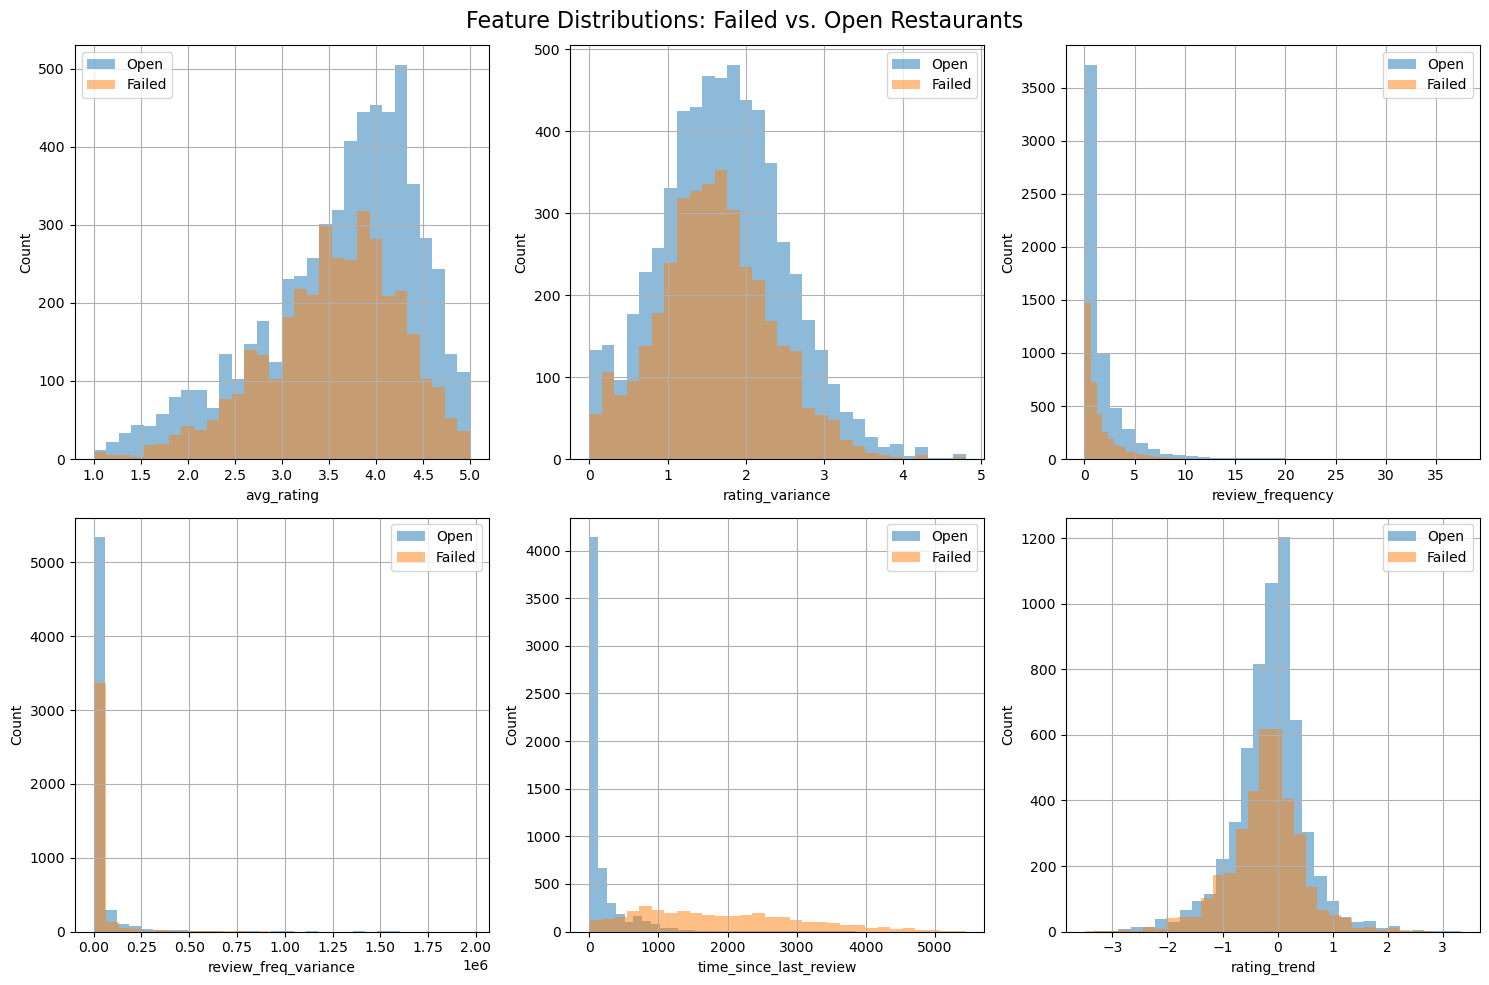


Correlation with failure:
failed                    1.000000
time_since_last_review    0.730774
review_freq_variance     -0.026181
review_frequency         -0.036627
avg_rating               -0.052033
rating_trend             -0.057421
rating_variance          -0.067187
Name: failed, dtype: float64


In [14]:
# Distribution of features by failure status
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions: Failed vs. Open Restaurants', fontsize=16)

feature_cols = ['avg_rating', 'rating_variance', 'review_frequency', 
                'review_freq_variance', 'time_since_last_review', 'rating_trend']

for idx, col in enumerate(feature_cols):
    ax = axes[idx // 3, idx % 3]
    
    features_df[features_df['failed'] == 0][col].hist(ax=ax, alpha=0.5, label='Open', bins=30)
    features_df[features_df['failed'] == 1][col].hist(ax=ax, alpha=0.5, label='Failed', bins=30)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation matrix
print("\nCorrelation with failure:")
correlations = features_df[feature_cols + ['failed']].corr()['failed'].sort_values(ascending=False)
print(correlations)

In [15]:
# Define feature columns
feature_columns = ['avg_rating', 'rating_variance', 'review_frequency', 
                   'review_freq_variance', 'time_since_last_review', 'rating_trend']

# Prepare datasets for each city
city_datasets = {}

for city in ['Tampa', 'Santa Barbara', 'Philadelphia']:
    city_data = features_df[features_df['city'] == city].copy()
    
    X = city_data[feature_columns]
    y = city_data['failed']
    
    # Split into train and test sets (80-20 split)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    city_datasets[city] = {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler,
        'feature_names': feature_columns
    }
    
    print(f"{city}:")
    print(f"  Training set: {len(X_train)} restaurants")
    print(f"  Test set: {len(X_test)} restaurants")
    print(f"  Failure rate (train): {y_train.mean()*100:.1f}%")
    print(f"  Failure rate (test): {y_test.mean()*100:.1f}%")
    print()

# Also create a combined dataset
X_all = features_df[feature_columns]
y_all = features_df['failed']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

city_datasets['Combined'] = {
    'X_train': X_train_all_scaled,
    'X_test': X_test_all_scaled,
    'y_train': y_train_all,
    'y_test': y_test_all,
    'scaler': scaler_all,
    'feature_names': feature_columns
}

print(f"Combined dataset:")
print(f"  Training set: {len(X_train_all)} restaurants")
print(f"  Test set: {len(X_test_all)} restaurants")

Tampa:
  Training set: 2368 restaurants
  Test set: 592 restaurants
  Failure rate (train): 33.7%
  Failure rate (test): 33.6%

Santa Barbara:
  Training set: 613 restaurants
  Test set: 154 restaurants
  Failure rate (train): 41.9%
  Failure rate (test): 41.6%

Philadelphia:
  Training set: 4681 restaurants
  Test set: 1171 restaurants
  Failure rate (train): 39.8%
  Failure rate (test): 39.8%

Combined dataset:
  Training set: 7663 restaurants
  Test set: 1916 restaurants


In [16]:
# Train Logistic Regression for each city
lr_models = {}
lr_results = []

print("="*80)
print("LOGISTIC REGRESSION RESULTS")
print("="*80)

for city_name, data in city_datasets.items():
    # Train model
    lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    lr.fit(data['X_train'], data['y_train'])
    
    # Predictions
    y_pred = lr.predict(data['X_test'])
    y_pred_proba = lr.predict_proba(data['X_test'])[:, 1]
    
    # Metrics
    accuracy = accuracy_score(data['y_test'], y_pred)
    precision = precision_score(data['y_test'], y_pred, zero_division=0)
    recall = recall_score(data['y_test'], y_pred, zero_division=0)
    f1 = f1_score(data['y_test'], y_pred, zero_division=0)
    roc_auc = roc_auc_score(data['y_test'], y_pred_proba) if len(np.unique(data['y_test'])) > 1 else 0
    
    lr_models[city_name] = lr
    
    lr_results.append({
        'City': city_name,
        'Model': 'Logistic Regression',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{city_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print("\n  Classification Report:")
    print(classification_report(data['y_test'], y_pred, target_names=['Open', 'Failed']))
    print("\n  Confusion Matrix:")
    print(confusion_matrix(data['y_test'], y_pred))

LOGISTIC REGRESSION RESULTS

Tampa:
  Accuracy:  0.9274
  Precision: 0.8939
  Recall:    0.8894
  F1-Score:  0.8917
  ROC-AUC:   0.9691

  Classification Report:
              precision    recall  f1-score   support

        Open       0.94      0.95      0.95       393
      Failed       0.89      0.89      0.89       199

    accuracy                           0.93       592
   macro avg       0.92      0.92      0.92       592
weighted avg       0.93      0.93      0.93       592


  Confusion Matrix:
[[372  21]
 [ 22 177]]

Santa Barbara:
  Accuracy:  0.9286
  Precision: 0.9492
  Recall:    0.8750
  F1-Score:  0.9106
  ROC-AUC:   0.9705

  Classification Report:
              precision    recall  f1-score   support

        Open       0.92      0.97      0.94        90
      Failed       0.95      0.88      0.91        64

    accuracy                           0.93       154
   macro avg       0.93      0.92      0.93       154
weighted avg       0.93      0.93      0.93       154

In [17]:
# Train Random Forest for each city
rf_models = {}
rf_results = []

print("="*80)
print("RANDOM FOREST RESULTS")
print("="*80)

for city_name, data in city_datasets.items():
    # Train model
    rf = RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        class_weight='balanced',
        max_depth=10,
        min_samples_split=10
    )
    rf.fit(data['X_train'], data['y_train'])
    
    # Predictions
    y_pred = rf.predict(data['X_test'])
    y_pred_proba = rf.predict_proba(data['X_test'])[:, 1]
    
    # Metrics
    accuracy = accuracy_score(data['y_test'], y_pred)
    precision = precision_score(data['y_test'], y_pred, zero_division=0)
    recall = recall_score(data['y_test'], y_pred, zero_division=0)
    f1 = f1_score(data['y_test'], y_pred, zero_division=0)
    roc_auc = roc_auc_score(data['y_test'], y_pred_proba) if len(np.unique(data['y_test'])) > 1 else 0
    
    rf_models[city_name] = rf
    
    rf_results.append({
        'City': city_name,
        'Model': 'Random Forest',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{city_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    # Feature importance
    print("\n  Feature Importance:")
    importances = pd.DataFrame({
        'Feature': data['feature_names'],
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(importances.to_string(index=False))

RANDOM FOREST RESULTS

Tampa:
  Accuracy:  0.9392
  Precision: 0.9015
  Recall:    0.9196
  F1-Score:  0.9104
  ROC-AUC:   0.9736

  Feature Importance:
               Feature  Importance
time_since_last_review    0.782662
      review_frequency    0.051842
            avg_rating    0.046163
  review_freq_variance    0.045494
       rating_variance    0.042133
          rating_trend    0.031706

Santa Barbara:
  Accuracy:  0.9545
  Precision: 0.9254
  Recall:    0.9688
  F1-Score:  0.9466
  ROC-AUC:   0.9733

  Feature Importance:
               Feature  Importance
time_since_last_review    0.741096
      review_frequency    0.061397
  review_freq_variance    0.055229
            avg_rating    0.054421
       rating_variance    0.044047
          rating_trend    0.043810

Philadelphia:
  Accuracy:  0.9163
  Precision: 0.8966
  Recall:    0.8927
  F1-Score:  0.8946
  ROC-AUC:   0.9686

  Feature Importance:
               Feature  Importance
time_since_last_review    0.765996
      revi

In [18]:
# Train Gradient Boosting for each city
gb_models = {}
gb_results = []

print("="*80)
print("GRADIENT BOOSTING RESULTS")
print("="*80)

for city_name, data in city_datasets.items():
    # Train model
    gb = GradientBoostingClassifier(
        n_estimators=100, 
        random_state=42,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=10
    )
    gb.fit(data['X_train'], data['y_train'])
    
    # Predictions
    y_pred = gb.predict(data['X_test'])
    y_pred_proba = gb.predict_proba(data['X_test'])[:, 1]
    
    # Metrics
    accuracy = accuracy_score(data['y_test'], y_pred)
    precision = precision_score(data['y_test'], y_pred, zero_division=0)
    recall = recall_score(data['y_test'], y_pred, zero_division=0)
    f1 = f1_score(data['y_test'], y_pred, zero_division=0)
    roc_auc = roc_auc_score(data['y_test'], y_pred_proba) if len(np.unique(data['y_test'])) > 1 else 0
    
    gb_models[city_name] = gb
    
    gb_results.append({
        'City': city_name,
        'Model': 'Gradient Boosting',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{city_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    # Feature importance
    print("\n  Feature Importance:")
    importances = pd.DataFrame({
        'Feature': data['feature_names'],
        'Importance': gb.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(importances.to_string(index=False))

GRADIENT BOOSTING RESULTS

Tampa:
  Accuracy:  0.9443
  Precision: 0.9278
  Recall:    0.9045
  F1-Score:  0.9160
  ROC-AUC:   0.9788

  Feature Importance:
               Feature  Importance
time_since_last_review    0.790640
      review_frequency    0.115029
  review_freq_variance    0.033405
            avg_rating    0.028401
       rating_variance    0.018436
          rating_trend    0.014089

Santa Barbara:
  Accuracy:  0.9286
  Precision: 0.9077
  Recall:    0.9219
  F1-Score:  0.9147
  ROC-AUC:   0.9543

  Feature Importance:
               Feature  Importance
time_since_last_review    0.791767
      review_frequency    0.091084
  review_freq_variance    0.057020
            avg_rating    0.029095
          rating_trend    0.015684
       rating_variance    0.015350

Philadelphia:
  Accuracy:  0.9146
  Precision: 0.9049
  Recall:    0.8777
  F1-Score:  0.8911
  ROC-AUC:   0.9694

  Feature Importance:
               Feature  Importance
time_since_last_review    0.775033
      

MODEL PERFORMANCE COMPARISON
         City               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
        Tampa Logistic Regression  0.927365   0.893939 0.889447  0.891688 0.969095
Santa Barbara Logistic Regression  0.928571   0.949153 0.875000  0.910569 0.970486
 Philadelphia Logistic Regression  0.904355   0.898649 0.856223  0.876923 0.955727
     Combined Logistic Regression  0.896660   0.857335 0.873800  0.865489 0.953481
        Tampa       Random Forest  0.939189   0.901478 0.919598  0.910448 0.973557
Santa Barbara       Random Forest  0.954545   0.925373 0.968750  0.946565 0.973264
 Philadelphia       Random Forest  0.916311   0.896552 0.892704  0.894624 0.968590
     Combined       Random Forest  0.921190   0.880263 0.917695  0.898590 0.970728
        Tampa   Gradient Boosting  0.944257   0.927835 0.904523  0.916031 0.978838
Santa Barbara   Gradient Boosting  0.928571   0.907692 0.921875  0.914729 0.954253
 Philadelphia   Gradient Boosting  0.914603   0.904867 0.8

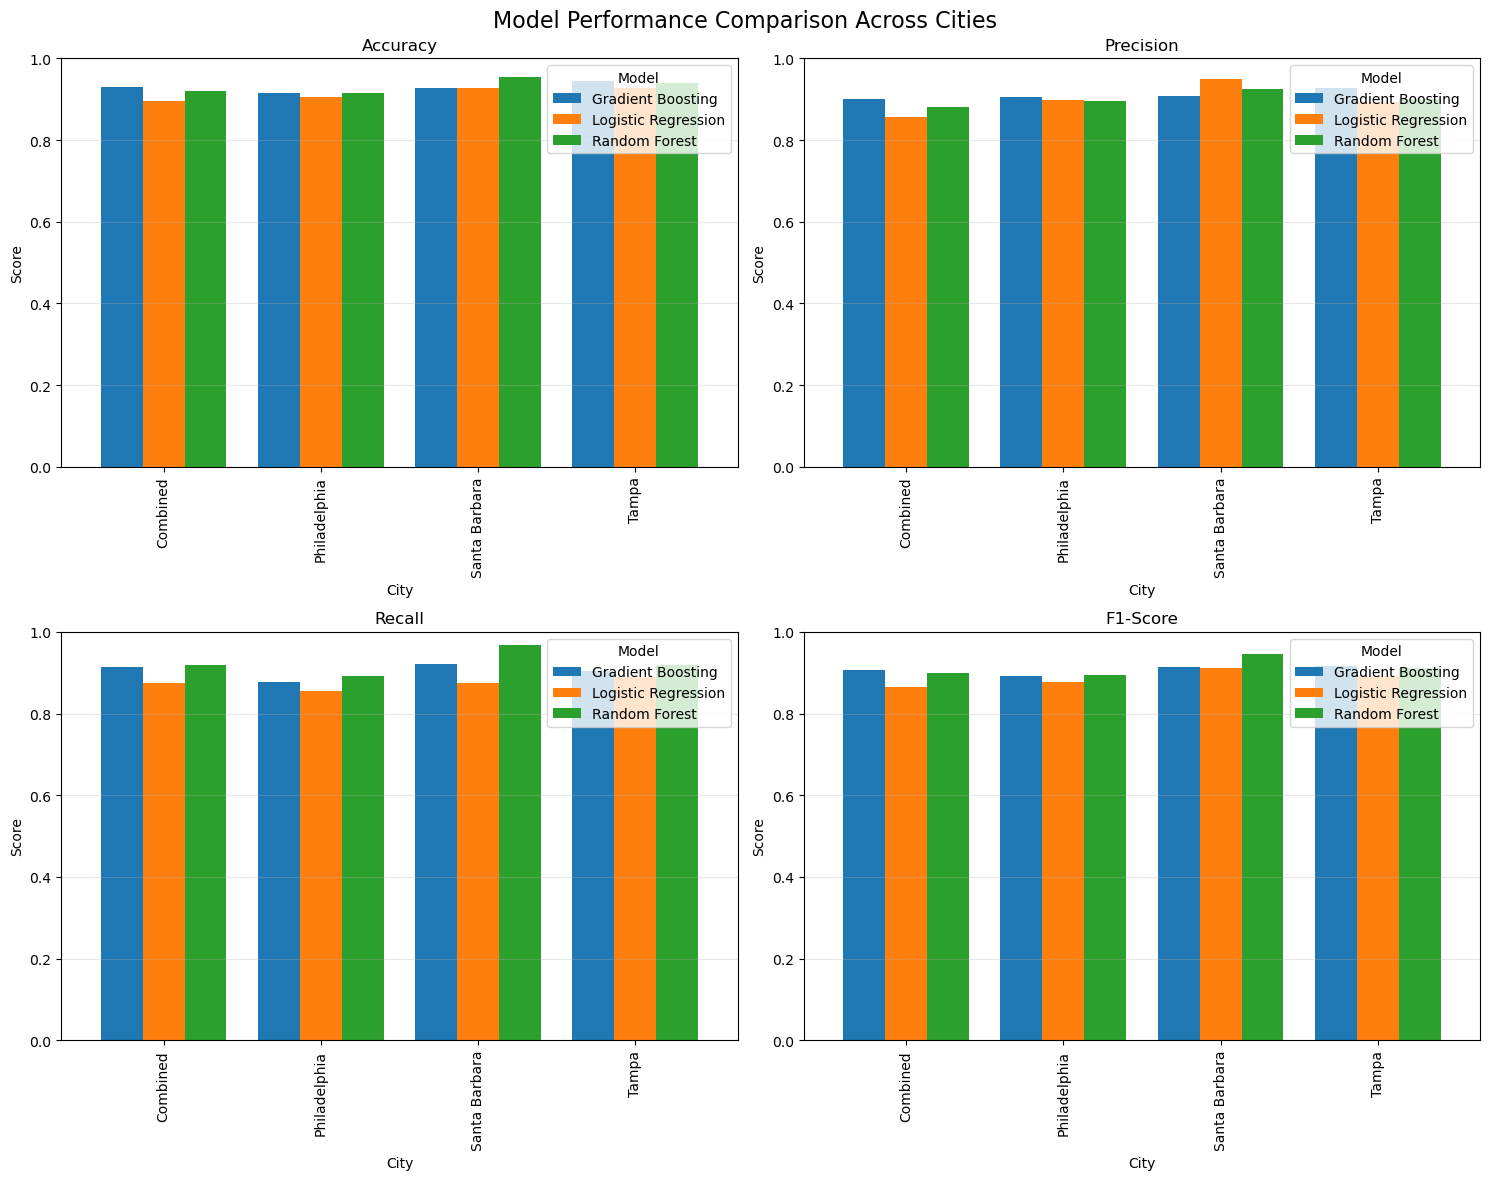

In [19]:
# Combine all results
all_results = pd.DataFrame(lr_results + rf_results + gb_results)

print("="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)
print(all_results.to_string(index=False))

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison Across Cities', fontsize=16)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Pivot data for plotting
    pivot_data = all_results.pivot(index='City', columns='Model', values=metric)
    pivot_data.plot(kind='bar', ax=ax, width=0.8)
    
    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.set_xlabel('City')
    ax.legend(title='Model')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Test model transferability across cities
cities = ['Tampa', 'Santa Barbara', 'Philadelphia']
transfer_results = []

print("="*100)
print("CROSS-CITY MODEL TRANSFER ANALYSIS")
print("="*100)
print("\nTraining a model on one city and testing on another...\n")

for train_city in cities:
    for test_city in cities:
        if train_city == test_city:
            continue
        
        # Use Random Forest model trained on train_city
        model = rf_models[train_city]
        
        # Test on test_city data
        test_data = city_datasets[test_city]
        y_pred = model.predict(test_data['X_test'])
        
        # Calculate metrics
        accuracy = accuracy_score(test_data['y_test'], y_pred)
        precision = precision_score(test_data['y_test'], y_pred, zero_division=0)
        recall = recall_score(test_data['y_test'], y_pred, zero_division=0)
        f1 = f1_score(test_data['y_test'], y_pred, zero_division=0)
        
        transfer_results.append({
            'Trained On': train_city,
            'Tested On': test_city,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
        
        print(f"Trained on {train_city}, Tested on {test_city}:")
        print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

transfer_df = pd.DataFrame(transfer_results)
print("\n" + "="*100)
print("TRANSFER LEARNING RESULTS")
print("="*100)
print(transfer_df.to_string(index=False))

CROSS-CITY MODEL TRANSFER ANALYSIS

Training a model on one city and testing on another...

Trained on Tampa, Tested on Santa Barbara:
  Accuracy: 0.9221, Precision: 0.9815, Recall: 0.8281, F1: 0.8983
Trained on Tampa, Tested on Philadelphia:
  Accuracy: 0.9112, Precision: 0.9190, Recall: 0.8519, F1: 0.8842
Trained on Santa Barbara, Tested on Tampa:
  Accuracy: 0.8666, Precision: 0.7273, Recall: 0.9648, F1: 0.8294
Trained on Santa Barbara, Tested on Philadelphia:
  Accuracy: 0.8847, Precision: 0.7961, Recall: 0.9549, F1: 0.8683
Trained on Philadelphia, Tested on Tampa:
  Accuracy: 0.9223, Precision: 0.8400, Recall: 0.9497, F1: 0.8915
Trained on Philadelphia, Tested on Santa Barbara:
  Accuracy: 0.9286, Precision: 0.9492, Recall: 0.8750, F1: 0.9106

TRANSFER LEARNING RESULTS
   Trained On     Tested On  Accuracy  Precision   Recall  F1-Score
        Tampa Santa Barbara  0.922078   0.981481 0.828125  0.898305
        Tampa  Philadelphia  0.911187   0.918981 0.851931  0.884187
Santa Barba

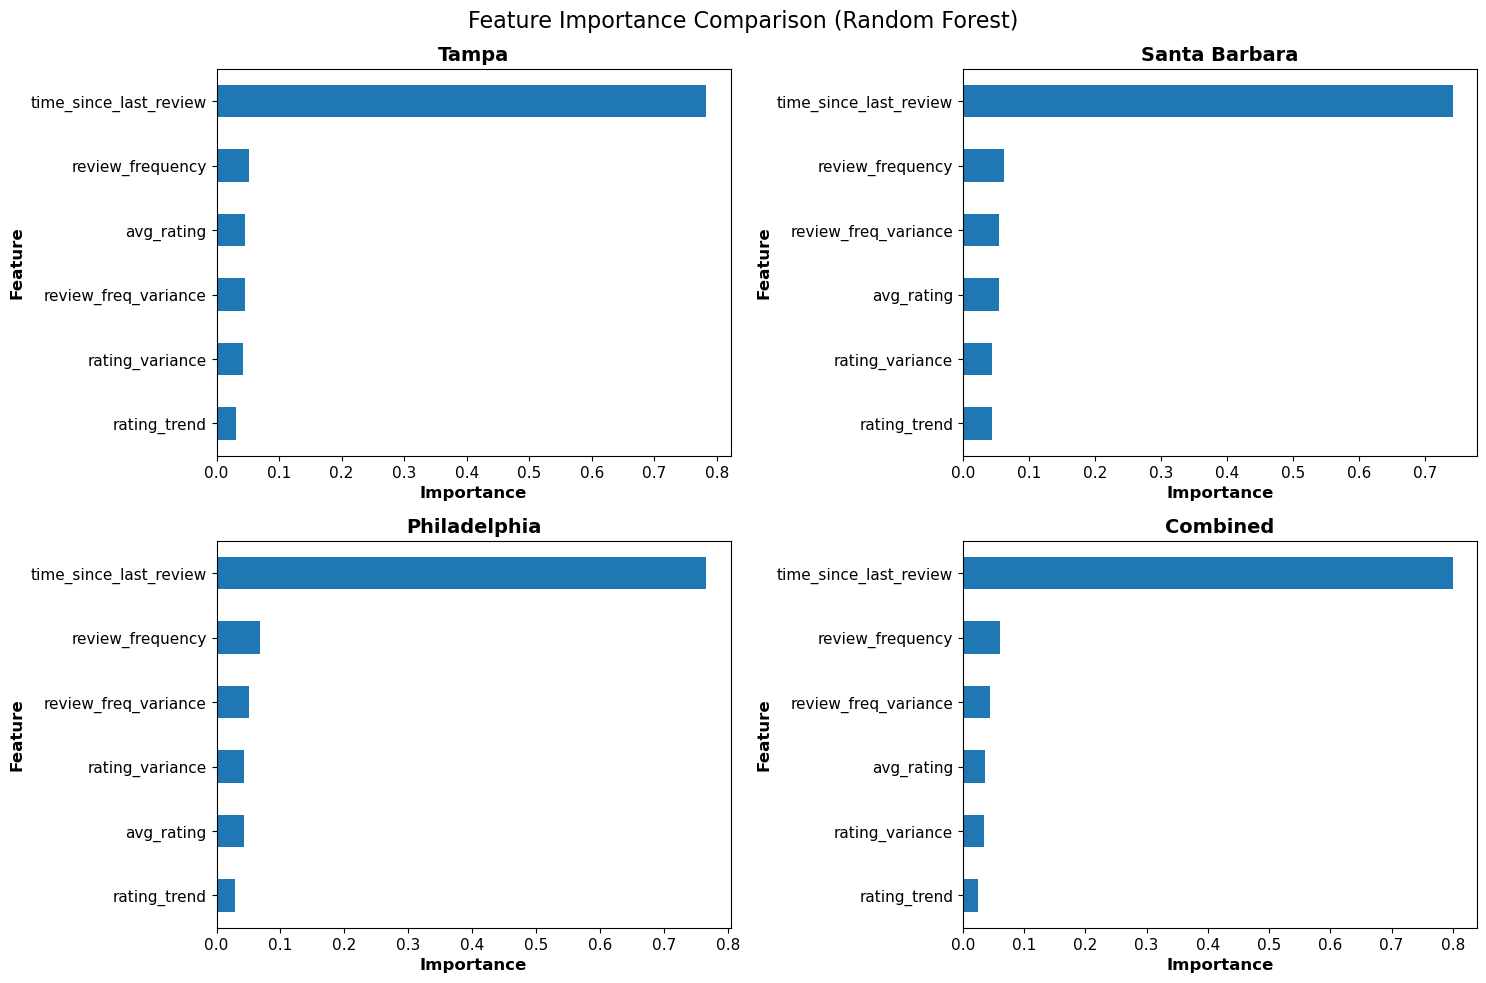

In [40]:
# Compare feature importance across cities
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Importance Comparison (Random Forest)', fontsize=16)

for idx, city_name in enumerate(['Tampa', 'Santa Barbara', 'Philadelphia', 'Combined']):
    ax = axes[idx // 2, idx % 2]
    
    model = rf_models[city_name]
    importances = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    importances.plot(x='Feature', y='Importance', kind='barh', ax=ax, legend=False)
    ax.set_title(city_name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
print("="*100)
print("KEY FINDINGS")
print("="*100)

# 1. Best performing model per city
print("\n1. BEST PERFORMING MODELS BY CITY (based on Precision):")
print("-" * 100)
for city in cities + ['Combined']:
    city_results = all_results[all_results['City'] == city]
    best_model = city_results.loc[city_results['Precision'].idxmax()]
    print(f"{city}: {best_model['Model']} (Precision: {best_model['Precision']:.4f})")

# 2. Most important features
print("\n2. TOP 3 MOST IMPORTANT FEATURES (Combined Model):")
print("-" * 100)
combined_importances = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_models['Combined'].feature_importances_
}).sort_values('Importance', ascending=False)
print(combined_importances.head(3).to_string(index=False))

# 3. Model transferability
print("\n3. MODEL TRANSFERABILITY:")
print("-" * 100)
avg_transfer_precision = transfer_df.groupby('Trained On')['Precision'].mean()
print("Average precision when model is transferred to other cities:")
print(avg_transfer_precision)

# 4. City-specific insights
print("\n4. CITY-SPECIFIC FAILURE RATES:")
print("-" * 100)
for city in cities:
    city_features = features_df[features_df['city'] == city]
    failure_rate = city_features['failed'].mean()
    avg_rating_failed = city_features[city_features['failed'] == 1]['avg_rating'].mean()
    avg_rating_open = city_features[city_features['failed'] == 0]['avg_rating'].mean()
    
    print(f"{city}:")
    print(f"  Failure rate: {failure_rate*100:.1f}%")
    print(f"  Avg rating (failed): {avg_rating_failed:.2f}")
    print(f"  Avg rating (open): {avg_rating_open:.2f}")
    print()

print("="*100)

KEY FINDINGS

1. BEST PERFORMING MODELS BY CITY (based on Precision):
----------------------------------------------------------------------------------------------------
Tampa: Gradient Boosting (Precision: 0.9278)
Santa Barbara: Logistic Regression (Precision: 0.9492)
Philadelphia: Gradient Boosting (Precision: 0.9049)
Combined: Gradient Boosting (Precision: 0.9012)

2. TOP 3 MOST IMPORTANT FEATURES (Combined Model):
----------------------------------------------------------------------------------------------------
               Feature  Importance
time_since_last_review    0.799477
      review_frequency    0.059935
  review_freq_variance    0.043819

3. MODEL TRANSFERABILITY:
----------------------------------------------------------------------------------------------------
Average precision when model is transferred to other cities:
Trained On
Philadelphia     0.894576
Santa Barbara    0.761669
Tampa            0.950231
Name: Precision, dtype: float64

4. CITY-SPECIFIC FAILURE 

In [23]:
# ==================================================================================================
# CONFUSION MATRIX'S
# ==================================================================================================

In [24]:
# Confusion Matrix Visualization for Restaurant Failure Prediction
# Focuses on models with best PRECISION (as emphasized in the abstract)
 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
 
# Function to create a professional confusion matrix visualization
def plot_confusion_matrix(y_true, y_pred, city_name, model_name, ax=None):
    """
    Create a confusion matrix heatmap with annotations
    
    Parameters:
    - y_true: actual labels
    - y_pred: predicted labels
    - city_name: name of city for title
    - model_name: name of model for title
    - ax: matplotlib axis (optional)
    """
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create labels with both counts and percentages
    labels = np.array([[f'{count}\n({percent:.1f}%)' 
                       for count, percent in zip(row_counts, row_percents)]
                      for row_counts, row_percents in zip(cm, cm_percent)])
    
    # Create plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot heatmap
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
                cbar_kws={'label': 'Count'},
                xticklabels=['Predicted Open', 'Predicted Failed'],
                yticklabels=['Actually Open', 'Actually Failed'],
                ax=ax, linewidths=2, linecolor='white')
    
    # Calculate and display key metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add title with metrics
    title = f'{city_name} - {model_name}\n'
    title += f'Precision: {precision:.3f} | Recall: {recall:.3f} | Accuracy: {accuracy:.3f}'
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
    
    return ax

Saved: confusion_matrices_all_models.png


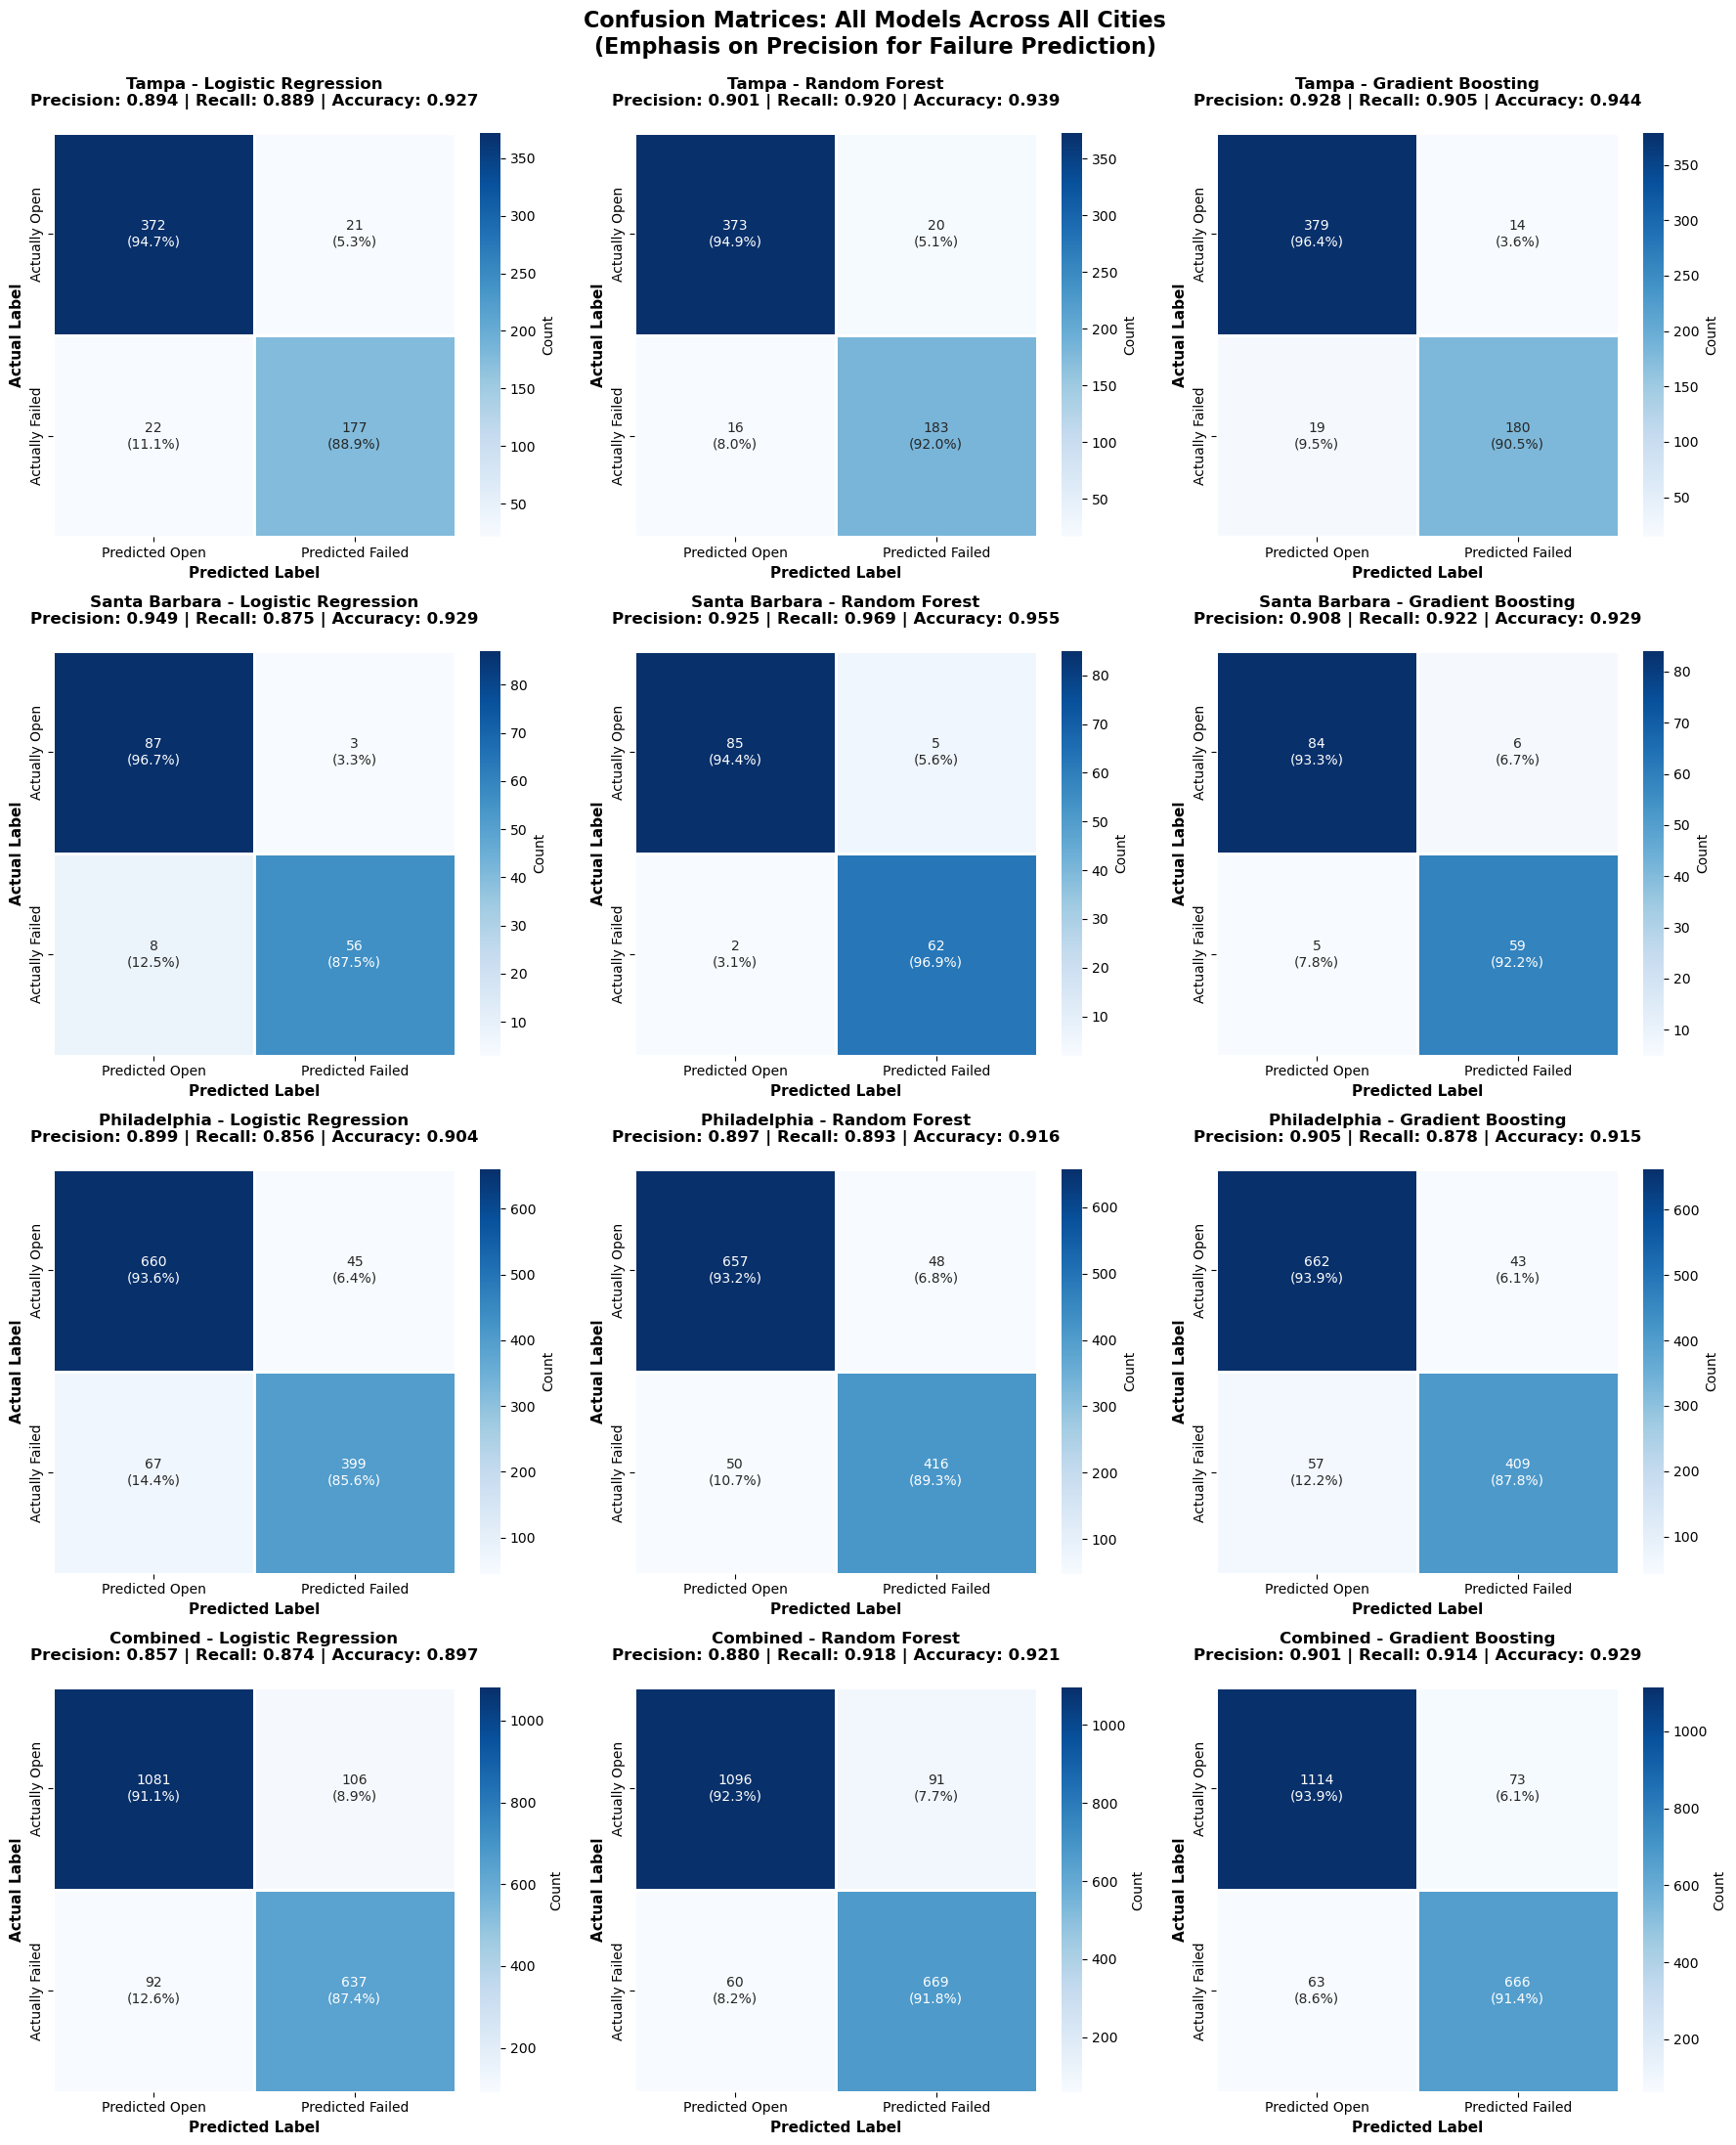

In [25]:
# ============================================================================
# OPTION 1: Create confusion matrices for ALL cities and models
# ============================================================================
 
# Create a large figure with subplots for each city and model
fig, axes = plt.subplots(4, 3, figsize=(18, 22))
fig.suptitle('Confusion Matrices: All Models Across All Cities\n(Emphasis on Precision for Failure Prediction)', 
             fontsize=16, fontweight='bold', y=0.995)
 
cities_list = ['Tampa', 'Santa Barbara', 'Philadelphia', 'Combined']
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
model_dict = {'Logistic Regression': lr_models, 
              'Random Forest': rf_models, 
              'Gradient Boosting': gb_models}
 
for city_idx, city in enumerate(cities_list):
    for model_idx, model_name in enumerate(models):
        ax = axes[city_idx, model_idx]
        
        # Get predictions
        model = model_dict[model_name][city]
        y_pred = model.predict(city_datasets[city]['X_test'])
        y_true = city_datasets[city]['y_test']
        
        # Plot confusion matrix
        plot_confusion_matrix(y_true, y_pred, city, model_name, ax)
 
plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
print("Saved: confusion_matrices_all_models.png")
plt.show()

Saved: confusion_matrices_best_models.png


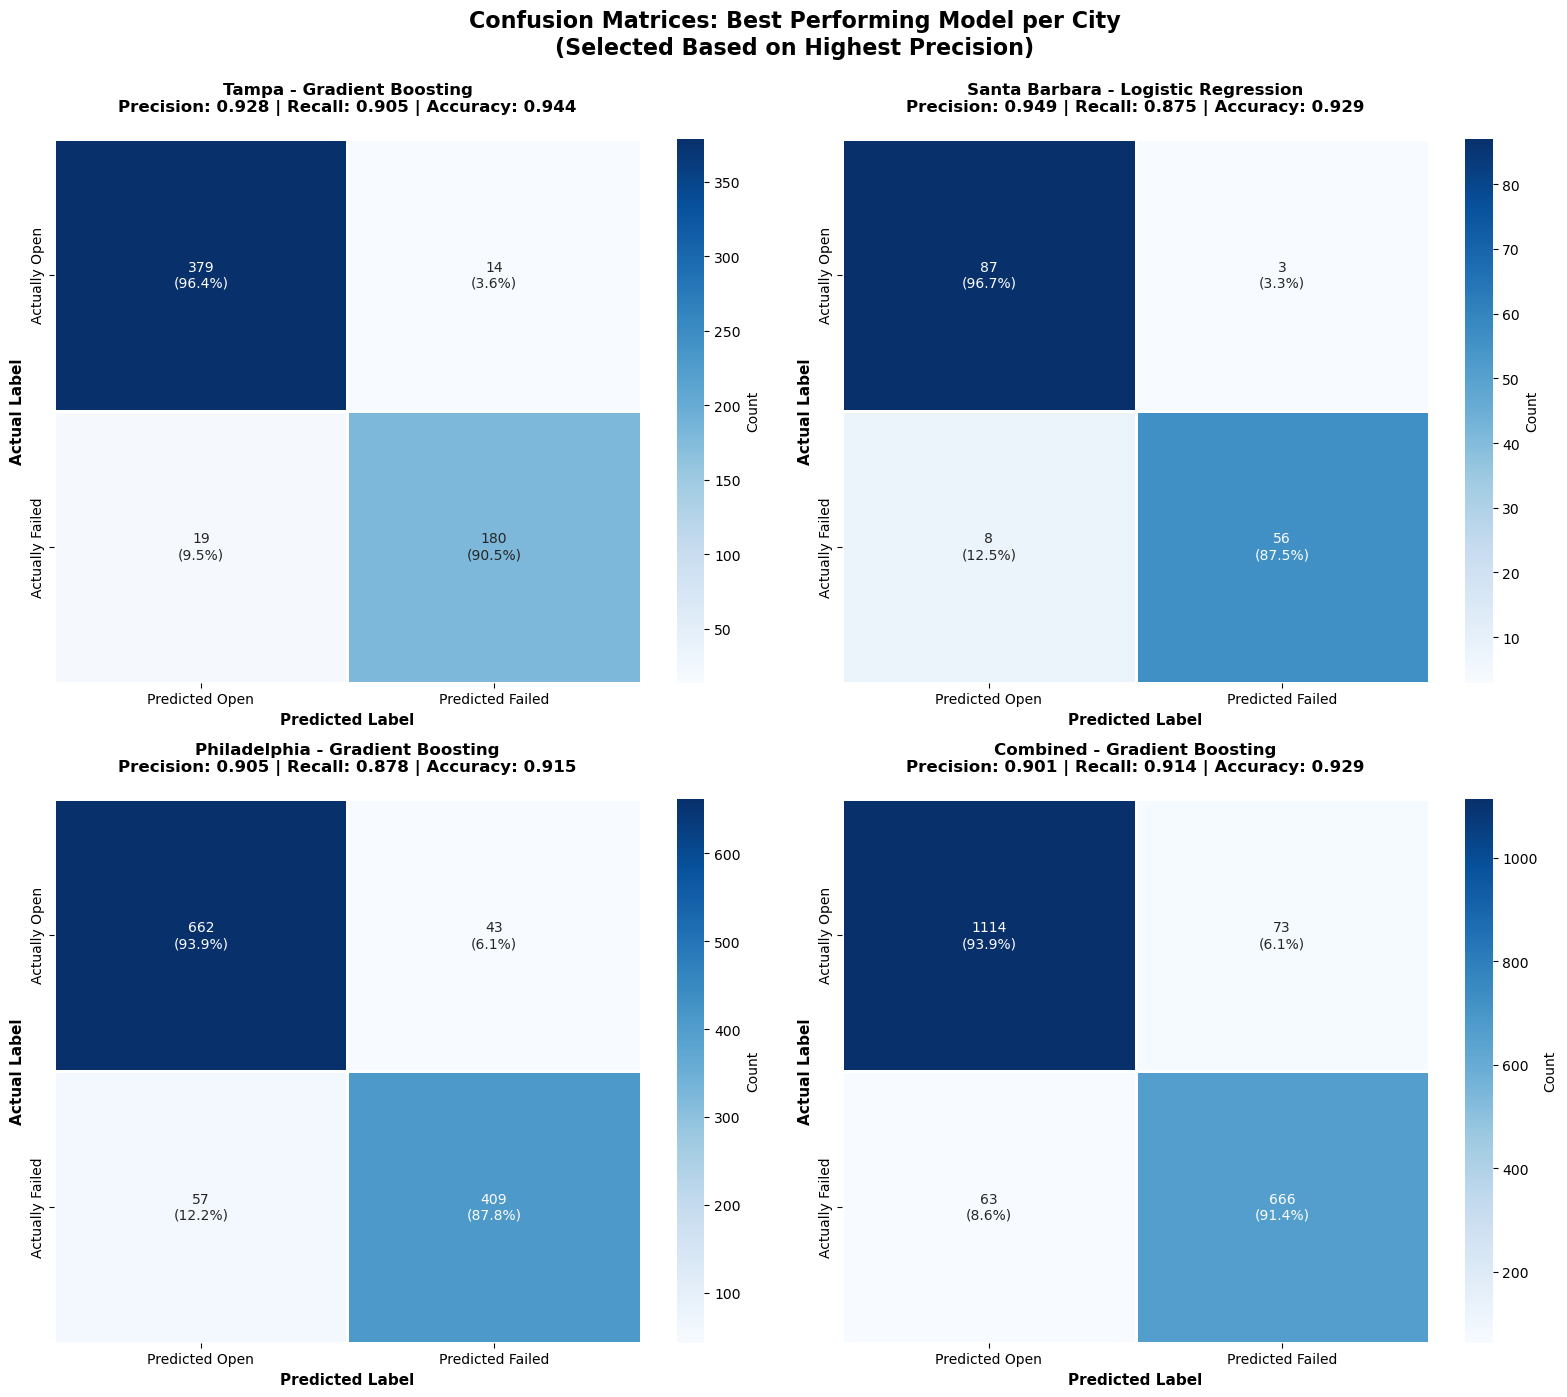

In [26]:
# ============================================================================
# OPTION 2: Create confusion matrices for BEST model per city (based on precision)
# ============================================================================
 
# Determine best model for each city based on precision
best_models_info = {}
 
for city in cities_list:
    best_precision = 0
    best_model_name = None
    best_model = None
    
    for model_name, model_dict_item in model_dict.items():
        model = model_dict_item[city]
        y_pred = model.predict(city_datasets[city]['X_test'])
        y_true = city_datasets[city]['y_test']
        
        from sklearn.metrics import precision_score
        precision = precision_score(y_true, y_pred, zero_division=0)
        
        if precision > best_precision:
            best_precision = precision
            best_model_name = model_name
            best_model = model
    
    best_models_info[city] = {
        'model_name': best_model_name,
        'model': best_model,
        'precision': best_precision
    }
 
# Create figure with best models only
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Confusion Matrices: Best Performing Model per City\n(Selected Based on Highest Precision)', 
             fontsize=16, fontweight='bold', y=0.995)
 
for idx, city in enumerate(cities_list):
    ax = axes[idx // 2, idx % 2]
    
    best_info = best_models_info[city]
    model = best_info['model']
    model_name = best_info['model_name']
    
    # Get predictions
    y_pred = model.predict(city_datasets[city]['X_test'])
    y_true = city_datasets[city]['y_test']
    
    # Plot confusion matrix
    plot_confusion_matrix(y_true, y_pred, city, model_name, ax)
 
plt.tight_layout()
plt.savefig('confusion_matrices_best_models.png', dpi=300, bbox_inches='tight')
print("Saved: confusion_matrices_best_models.png")
plt.show()


Key Insights:
• True Negatives (TN): 1,096 restaurants correctly predicted as OPEN
• False Positives (FP): 91 restaurants predicted to FAIL but actually OPEN (Type I Error)
• False Negatives (FN): 60 restaurants predicted as OPEN but actually FAILED (Type II Error)
• True Positives (TP): 669 restaurants correctly predicted as FAILED

Precision of 88.0% means 88.0% of failure predictions are correct.
This minimizes false alarms for business owners and investors.


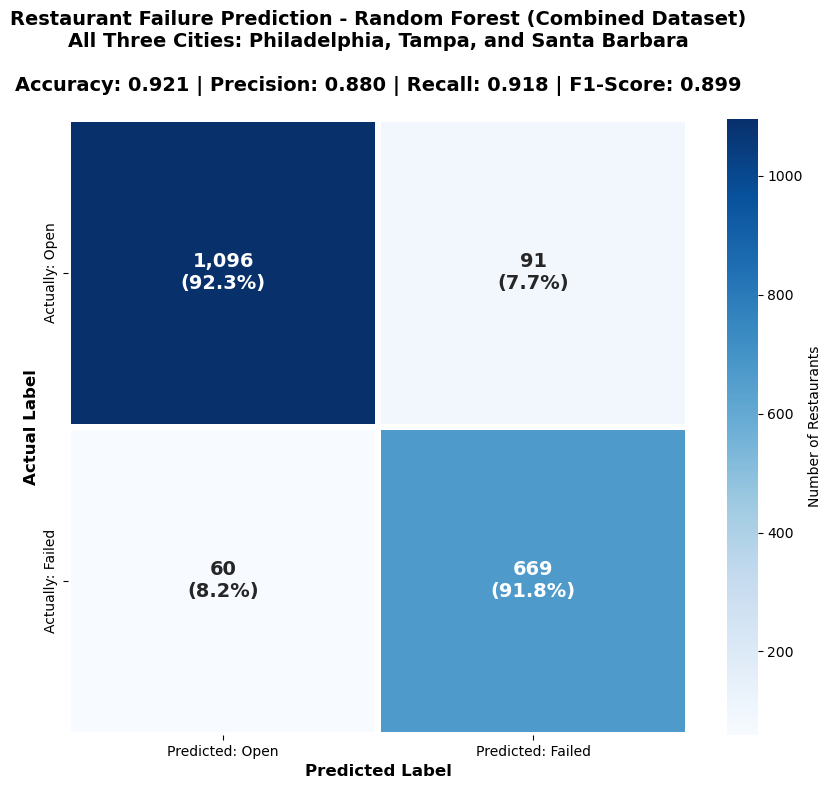

In [27]:
# ============================================================================
# OPTION 3: Single large confusion matrix for Combined model (Random Forest)
# ============================================================================
 
# Use Random Forest on Combined dataset (typically best performer)
fig, ax = plt.subplots(figsize=(10, 8))
 
model = rf_models['Combined']
y_pred = model.predict(city_datasets['Combined']['X_test'])
y_true = city_datasets['Combined']['y_test']
 
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
 
# Create detailed labels
labels = np.array([[f'{count:,}\n({percent:.1f}%)' 
                   for count, percent in zip(row_counts, row_percents)]
                  for row_counts, row_percents in zip(cm, cm_percent)])
 
# Plot
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
            cbar_kws={'label': 'Number of Restaurants'},
            xticklabels=['Predicted: Open', 'Predicted: Failed'],
            yticklabels=['Actually: Open', 'Actually: Failed'],
            ax=ax, linewidths=3, linecolor='white',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
 
# Calculate metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
 
# Enhanced title
title = 'Restaurant Failure Prediction - Random Forest (Combined Dataset)\n'
title += f'All Three Cities: Philadelphia, Tampa, and Santa Barbara\n\n'
title += f'Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1-Score: {f1:.3f}'
ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
 
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')

# Print interpretation to console instead
print("\nKey Insights:")
print(f"• True Negatives (TN): {tn:,} restaurants correctly predicted as OPEN")
print(f"• False Positives (FP): {fp:,} restaurants predicted to FAIL but actually OPEN (Type I Error)")
print(f"• False Negatives (FN): {fn:,} restaurants predicted as OPEN but actually FAILED (Type II Error)")
print(f"• True Positives (TP): {tp:,} restaurants correctly predicted as FAILED")
print(f"\nPrecision of {precision:.1%} means {precision*100:.1f}% of failure predictions are correct.")
print("This minimizes false alarms for business owners and investors.")

Saved: confusion_matrix_comparison.png


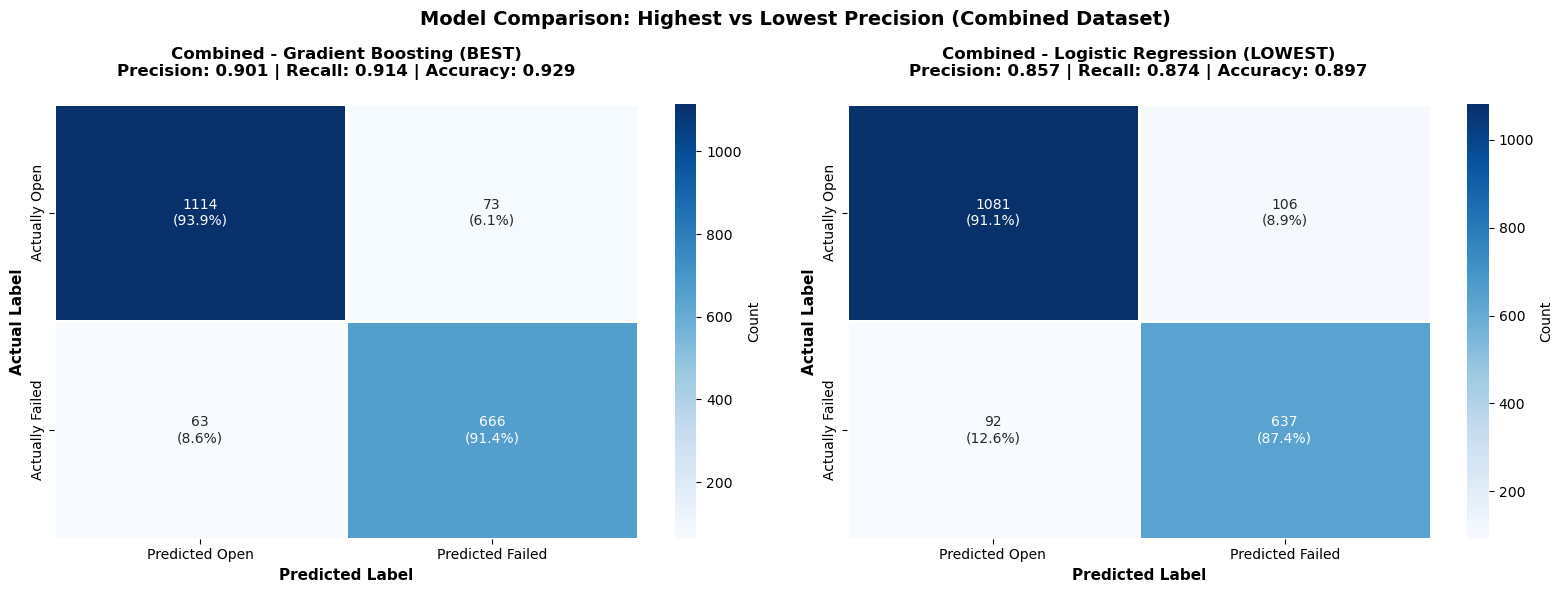

In [28]:
# ============================================================================
# OPTION 4: Side-by-side comparison of best vs worst precision models
# ============================================================================
 
# Find model with best and worst precision in Combined dataset
model_precisions = {}
for model_name, model_dict_item in model_dict.items():
    model = model_dict_item['Combined']
    y_pred = model.predict(city_datasets['Combined']['X_test'])
    y_true = city_datasets['Combined']['y_test']
    precision = precision_score(y_true, y_pred, zero_division=0)
    model_precisions[model_name] = {'model': model, 'precision': precision}
 
best_model_name = max(model_precisions, key=lambda k: model_precisions[k]['precision'])
worst_model_name = min(model_precisions, key=lambda k: model_precisions[k]['precision'])
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison: Highest vs Lowest Precision (Combined Dataset)', 
             fontsize=14, fontweight='bold')
 
# Plot best model
ax = axes[0]
model = model_precisions[best_model_name]['model']
y_pred = model.predict(city_datasets['Combined']['X_test'])
y_true = city_datasets['Combined']['y_test']
plot_confusion_matrix(y_true, y_pred, 'Combined', f'{best_model_name} (BEST)', ax)
 
# Plot worst model
ax = axes[1]
model = model_precisions[worst_model_name]['model']
y_pred = model.predict(city_datasets['Combined']['X_test'])
y_true = city_datasets['Combined']['y_test']
plot_confusion_matrix(y_true, y_pred, 'Combined', f'{worst_model_name} (LOWEST)', ax)
 
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: confusion_matrix_comparison.png")
plt.show()

In [29]:
# ============================================================================
# Print Summary
# ============================================================================
 
print("\n" + "="*80)
print("CONFUSION MATRIX VISUALIZATIONS CREATED")
print("="*80)
print("\nFiles saved:")
print("1. confusion_matrices_all_models.png - All 12 combinations (3 models × 4 datasets)")
print("2. confusion_matrices_best_models.png - Best model for each city (4 matrices)")
print("3. confusion_matrix_combined_model.png - Single detailed matrix for Combined RF model")
print("4. confusion_matrix_comparison.png - Best vs worst precision models side-by-side")
print("\nBest models by city (based on precision):")
for city, info in best_models_info.items():
    print(f"  {city}: {info['model_name']} (Precision: {info['precision']:.4f})")
print("="*80)


CONFUSION MATRIX VISUALIZATIONS CREATED

Files saved:
1. confusion_matrices_all_models.png - All 12 combinations (3 models × 4 datasets)
2. confusion_matrices_best_models.png - Best model for each city (4 matrices)
3. confusion_matrix_combined_model.png - Single detailed matrix for Combined RF model
4. confusion_matrix_comparison.png - Best vs worst precision models side-by-side

Best models by city (based on precision):
  Tampa: Gradient Boosting (Precision: 0.9278)
  Santa Barbara: Logistic Regression (Precision: 0.9492)
  Philadelphia: Gradient Boosting (Precision: 0.9049)
  Combined: Gradient Boosting (Precision: 0.9012)


In [30]:
# ==============================================================================
# 1 AND 2 STAR ANALYSIS ONLY
# ==============================================================================

In [31]:
# ============================================================================
# 1. Overall Distribution of Low-Star Reviews
# ============================================================================
 
print("\n1. OVERALL LOW-STAR REVIEW DISTRIBUTION")
print("-"*80)
 
# Count reviews by star rating
one_star_reviews = merged_data[merged_data['stars_review'] == 1]
two_star_reviews = merged_data[merged_data['stars_review'] == 2]
low_star_reviews = merged_data[merged_data['stars_review'].isin([1, 2])]
 
print(f"Total 1-star reviews: {len(one_star_reviews):,} ({len(one_star_reviews)/len(merged_data)*100:.1f}%)")
print(f"Total 2-star reviews: {len(two_star_reviews):,} ({len(two_star_reviews)/len(merged_data)*100:.1f}%)")
print(f"Total low-star (1-2) reviews: {len(low_star_reviews):,} ({len(low_star_reviews)/len(merged_data)*100:.1f}%)")


1. OVERALL LOW-STAR REVIEW DISTRIBUTION
--------------------------------------------------------------------------------
Total 1-star reviews: 117,346 (10.2%)
Total 2-star reviews: 93,523 (8.1%)
Total low-star (1-2) reviews: 210,869 (18.3%)


In [32]:
# ============================================================================
# 2. Low-Star Reviews by Restaurant Status
# ============================================================================
 
print("\n2. LOW-STAR REVIEWS BY RESTAURANT STATUS (OPEN vs CLOSED)")
print("-"*80)
 
# Separate by open/closed status
open_restaurants = merged_data[merged_data['is_open'] == 1]
closed_restaurants = merged_data[merged_data['is_open'] == 0]
 
# Count low-star reviews for each status
open_one_star = len(open_restaurants[open_restaurants['stars_review'] == 1])
open_two_star = len(open_restaurants[open_restaurants['stars_review'] == 2])
open_low_star = len(open_restaurants[open_restaurants['stars_review'].isin([1, 2])])
 
closed_one_star = len(closed_restaurants[closed_restaurants['stars_review'] == 1])
closed_two_star = len(closed_restaurants[closed_restaurants['stars_review'] == 2])
closed_low_star = len(closed_restaurants[closed_restaurants['stars_review'].isin([1, 2])])
 
print(f"\nOPEN Restaurants:")
print(f"  1-star reviews: {open_one_star:,} ({open_one_star/len(open_restaurants)*100:.1f}% of open restaurant reviews)")
print(f"  2-star reviews: {open_two_star:,} ({open_two_star/len(open_restaurants)*100:.1f}%)")
print(f"  Total low-star: {open_low_star:,} ({open_low_star/len(open_restaurants)*100:.1f}%)")
 
print(f"\nCLOSED Restaurants:")
print(f"  1-star reviews: {closed_one_star:,} ({closed_one_star/len(closed_restaurants)*100:.1f}% of closed restaurant reviews)")
print(f"  2-star reviews: {closed_two_star:,} ({closed_two_star/len(closed_restaurants)*100:.1f}%)")
print(f"  Total low-star: {closed_low_star:,} ({closed_low_star/len(closed_restaurants)*100:.1f}%)")
 
# Calculate difference
print(f"\nDIFFERENCE (Closed - Open):")
print(f"  1-star: {closed_one_star/len(closed_restaurants)*100 - open_one_star/len(open_restaurants)*100:+.1f} percentage points")
print(f"  2-star: {closed_two_star/len(closed_restaurants)*100 - open_two_star/len(open_restaurants)*100:+.1f} percentage points")
print(f"  Total low-star: {closed_low_star/len(closed_restaurants)*100 - open_low_star/len(open_restaurants)*100:+.1f} percentage points")


2. LOW-STAR REVIEWS BY RESTAURANT STATUS (OPEN vs CLOSED)
--------------------------------------------------------------------------------

OPEN Restaurants:
  1-star reviews: 87,493 (9.9% of open restaurant reviews)
  2-star reviews: 66,540 (7.5%)
  Total low-star: 154,033 (17.4%)

CLOSED Restaurants:
  1-star reviews: 29,853 (11.2% of closed restaurant reviews)
  2-star reviews: 26,983 (10.1%)
  Total low-star: 56,836 (21.3%)

DIFFERENCE (Closed - Open):
  1-star: +1.3 percentage points
  2-star: +2.6 percentage points
  Total low-star: +3.9 percentage points


In [33]:
# ============================================================================
# 3. City-Specific Analysis
# ============================================================================
 
print("\n3. LOW-STAR REVIEWS BY CITY AND STATUS")
print("-"*80)
 
cities = ['Tampa', 'Santa Barbara', 'Philadelphia']
 
for city in cities:
    city_data = merged_data[merged_data['city'] == city]
    city_open = city_data[city_data['is_open'] == 1]
    city_closed = city_data[city_data['is_open'] == 0]
    
    open_low_pct = len(city_open[city_open['stars_review'].isin([1, 2])]) / len(city_open) * 100 if len(city_open) > 0 else 0
    closed_low_pct = len(city_closed[city_closed['stars_review'].isin([1, 2])]) / len(city_closed) * 100 if len(city_closed) > 0 else 0
    
    print(f"\n{city}:")
    print(f"  Open restaurants - Low-star reviews: {open_low_pct:.1f}%")
    print(f"  Closed restaurants - Low-star reviews: {closed_low_pct:.1f}%")
    print(f"  Difference: {closed_low_pct - open_low_pct:+.1f} percentage points")


3. LOW-STAR REVIEWS BY CITY AND STATUS
--------------------------------------------------------------------------------

Tampa:
  Open restaurants - Low-star reviews: 18.9%
  Closed restaurants - Low-star reviews: 22.7%
  Difference: +3.8 percentage points

Santa Barbara:
  Open restaurants - Low-star reviews: 15.7%
  Closed restaurants - Low-star reviews: 21.0%
  Difference: +5.3 percentage points

Philadelphia:
  Open restaurants - Low-star reviews: 17.1%
  Closed restaurants - Low-star reviews: 20.9%
  Difference: +3.8 percentage points


In [34]:
# ============================================================================
# 4. Restaurant-Level Analysis: Average Low-Star Percentage
# ============================================================================
 
print("\n4. RESTAURANT-LEVEL ANALYSIS: AVERAGE LOW-STAR PERCENTAGE PER RESTAURANT")
print("-"*80)
 
# Calculate low-star percentage for each restaurant
restaurant_stats = []
 
for business_id, group in merged_data.groupby('business_id'):
    total_reviews = len(group)
    low_star_count = len(group[group['stars_review'].isin([1, 2])])
    low_star_pct = (low_star_count / total_reviews * 100) if total_reviews > 0 else 0
    is_open = group['is_open'].iloc[0]
    city = group['city'].iloc[0]
    
    restaurant_stats.append({
        'business_id': business_id,
        'city': city,
        'is_open': is_open,
        'total_reviews': total_reviews,
        'low_star_count': low_star_count,
        'low_star_percentage': low_star_pct
    })
 
restaurant_df = pd.DataFrame(restaurant_stats)
 
# Compare averages
open_avg = restaurant_df[restaurant_df['is_open'] == 1]['low_star_percentage'].mean()
closed_avg = restaurant_df[restaurant_df['is_open'] == 0]['low_star_percentage'].mean()
 
print(f"Average low-star percentage per restaurant:")
print(f"  OPEN restaurants: {open_avg:.2f}%")
print(f"  CLOSED restaurants: {closed_avg:.2f}%")
print(f"  Difference: {closed_avg - open_avg:+.2f} percentage points")
 
# Statistical test
from scipy import stats
open_values = restaurant_df[restaurant_df['is_open'] == 1]['low_star_percentage']
closed_values = restaurant_df[restaurant_df['is_open'] == 0]['low_star_percentage']
t_stat, p_value = stats.ttest_ind(closed_values, open_values)
 
print(f"\nStatistical Significance (t-test):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant? {'YES - Closed restaurants have significantly more low-star reviews' if p_value < 0.05 else 'NO'}")


4. RESTAURANT-LEVEL ANALYSIS: AVERAGE LOW-STAR PERCENTAGE PER RESTAURANT
--------------------------------------------------------------------------------
Average low-star percentage per restaurant:
  OPEN restaurants: 25.84%
  CLOSED restaurants: 25.41%
  Difference: -0.43 percentage points

Statistical Significance (t-test):
  t-statistic: -0.9811
  p-value: 3.2658e-01
  Significant? NO


In [35]:
# ============================================================================
# 5. Distribution Analysis: Low-Star Review Counts
# ============================================================================
 
print("\n5. DISTRIBUTION OF LOW-STAR REVIEW COUNTS")
print("-"*80)
 
# Bins for low-star review counts
bins = [0, 5, 10, 20, 50, 100, 500]
labels = ['0-5', '6-10', '11-20', '21-50', '51-100', '100+']
 
restaurant_df['low_star_bin'] = pd.cut(restaurant_df['low_star_count'], bins=bins, labels=labels, include_lowest=True)
 
print("\nDistribution of restaurants by low-star review count:")
print("\nOPEN Restaurants:")
open_dist = restaurant_df[restaurant_df['is_open'] == 1]['low_star_bin'].value_counts(normalize=True).sort_index() * 100
print(open_dist.to_string())
 
print("\nCLOSED Restaurants:")
closed_dist = restaurant_df[restaurant_df['is_open'] == 0]['low_star_bin'].value_counts(normalize=True).sort_index() * 100
print(closed_dist.to_string())


5. DISTRIBUTION OF LOW-STAR REVIEW COUNTS
--------------------------------------------------------------------------------

Distribution of restaurants by low-star review count:

OPEN Restaurants:
low_star_bin
0-5       33.063564
6-10      15.899511
11-20     16.978587
21-50     19.372787
51-100    10.251222
100+       4.434328

CLOSED Restaurants:
low_star_bin
0-5       44.813392
6-10      16.163557
11-20     15.944018
21-50     16.245884
51-100     5.049396
100+       1.783754



Visualization saved: low_star_reviews_analysis.png


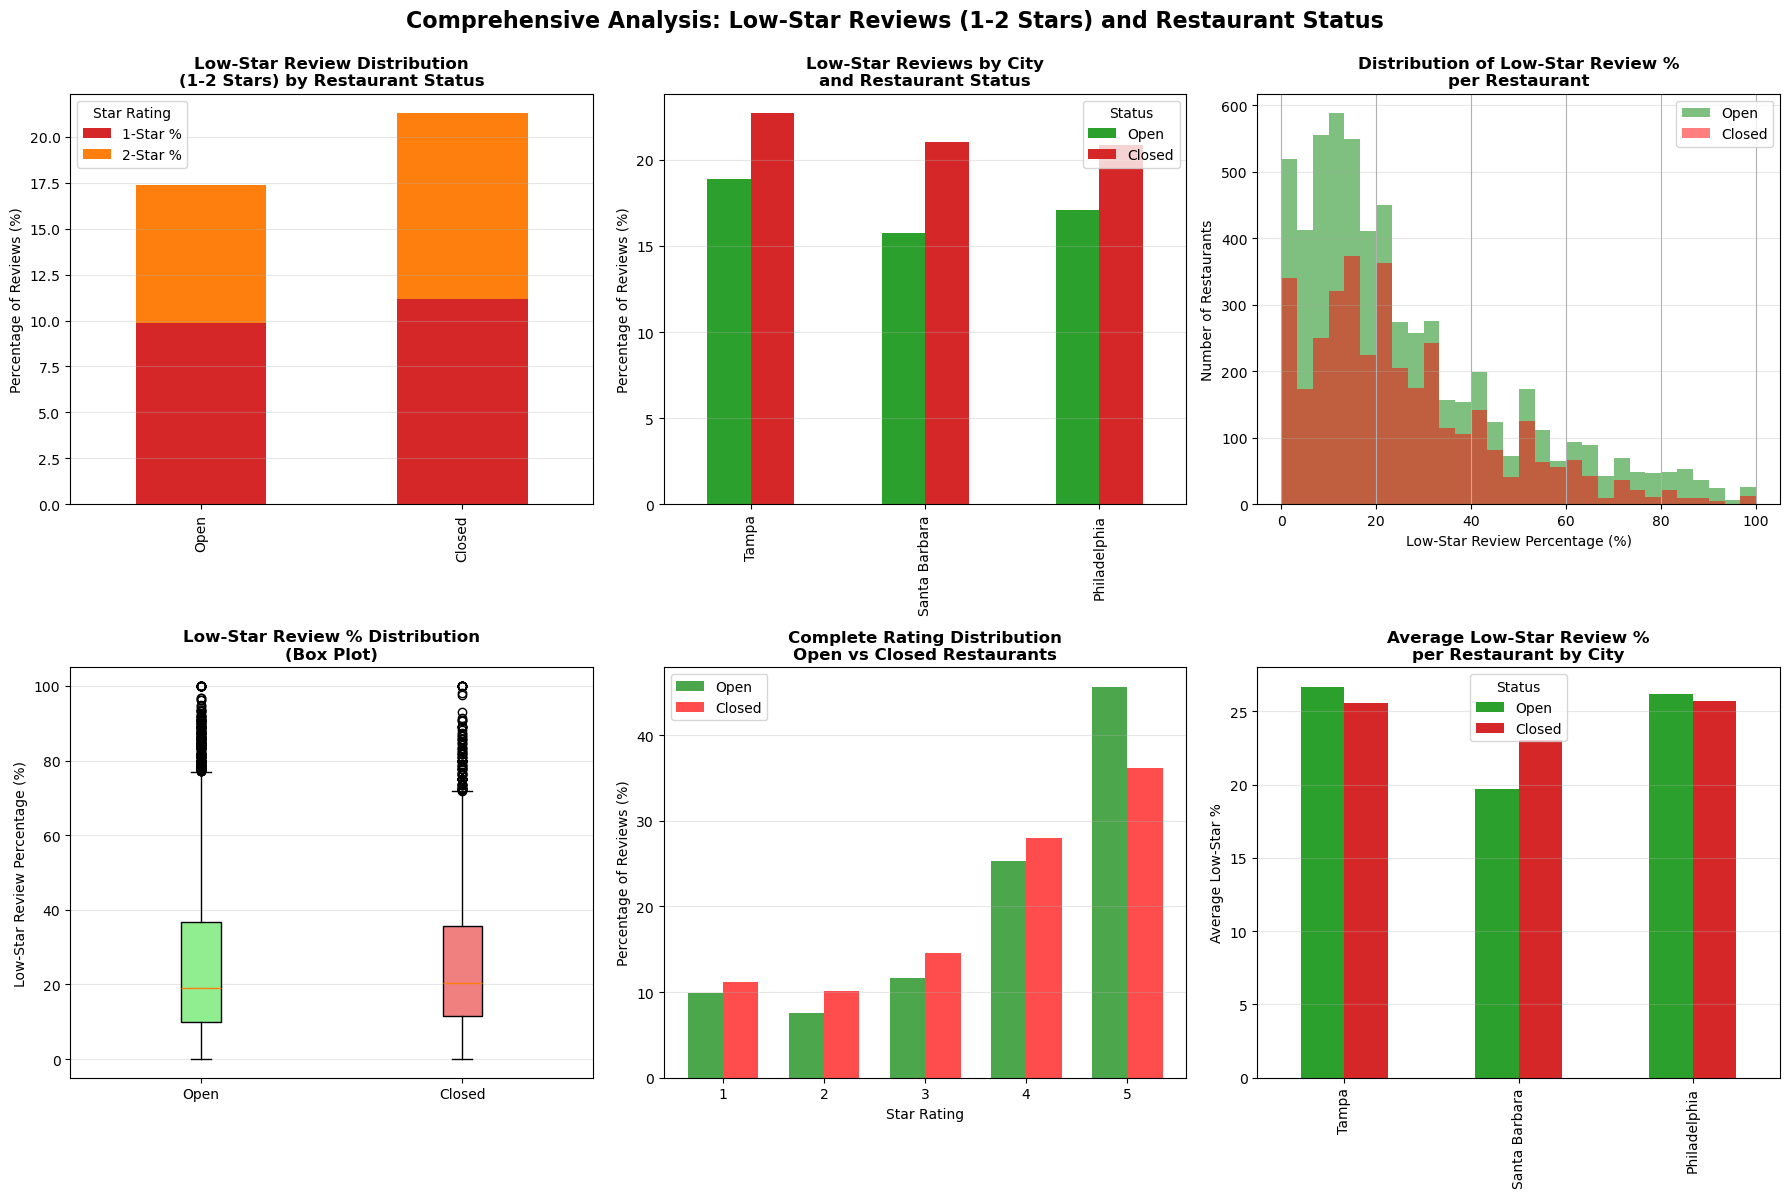

In [36]:
# ============================================================================
# 6. VISUALIZATIONS
# ============================================================================
 
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
 
# Plot 1: Overall comparison - Low-star percentage by status
ax1 = plt.subplot(2, 3, 1)
status_data = pd.DataFrame({
    'Status': ['Open', 'Closed'],
    '1-Star %': [open_one_star/len(open_restaurants)*100, closed_one_star/len(closed_restaurants)*100],
    '2-Star %': [open_two_star/len(open_restaurants)*100, closed_two_star/len(closed_restaurants)*100]
})
status_data.plot(x='Status', kind='bar', stacked=True, ax=ax1, color=['#d62728', '#ff7f0e'])
ax1.set_title('Low-Star Review Distribution\n(1-2 Stars) by Restaurant Status', fontweight='bold')
ax1.set_ylabel('Percentage of Reviews (%)')
ax1.set_xlabel('')
ax1.legend(title='Star Rating')
ax1.grid(axis='y', alpha=0.3)
 
# Plot 2: City comparison
ax2 = plt.subplot(2, 3, 2)
city_comparison = []
for city in cities:
    city_data = merged_data[merged_data['city'] == city]
    city_open = city_data[city_data['is_open'] == 1]
    city_closed = city_data[city_data['is_open'] == 0]
    
    city_comparison.append({
        'City': city,
        'Open': len(city_open[city_open['stars_review'].isin([1, 2])]) / len(city_open) * 100 if len(city_open) > 0 else 0,
        'Closed': len(city_closed[city_closed['stars_review'].isin([1, 2])]) / len(city_closed) * 100 if len(city_closed) > 0 else 0
    })
 
city_df = pd.DataFrame(city_comparison)
city_df.plot(x='City', kind='bar', ax=ax2, color=['#2ca02c', '#d62728'])
ax2.set_title('Low-Star Reviews by City\nand Restaurant Status', fontweight='bold')
ax2.set_ylabel('Percentage of Reviews (%)')
ax2.set_xlabel('')
ax2.legend(title='Status')
ax2.grid(axis='y', alpha=0.3)
 
# Plot 3: Distribution of low-star percentages
ax3 = plt.subplot(2, 3, 3)
restaurant_df[restaurant_df['is_open'] == 1]['low_star_percentage'].hist(
    bins=30, alpha=0.5, label='Open', color='green', ax=ax3
)
restaurant_df[restaurant_df['is_open'] == 0]['low_star_percentage'].hist(
    bins=30, alpha=0.5, label='Closed', color='red', ax=ax3
)
ax3.set_title('Distribution of Low-Star Review %\nper Restaurant', fontweight='bold')
ax3.set_xlabel('Low-Star Review Percentage (%)')
ax3.set_ylabel('Number of Restaurants')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
 
# Plot 4: Box plot comparison
ax4 = plt.subplot(2, 3, 4)
box_data = [
    restaurant_df[restaurant_df['is_open'] == 1]['low_star_percentage'],
    restaurant_df[restaurant_df['is_open'] == 0]['low_star_percentage']
]
bp = ax4.boxplot(box_data, labels=['Open', 'Closed'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
ax4.set_title('Low-Star Review % Distribution\n(Box Plot)', fontweight='bold')
ax4.set_ylabel('Low-Star Review Percentage (%)')
ax4.grid(axis='y', alpha=0.3)
 
# Plot 5: Full rating distribution comparison
ax5 = plt.subplot(2, 3, 5)
open_ratings = open_restaurants['stars_review'].value_counts(normalize=True).sort_index() * 100
closed_ratings = closed_restaurants['stars_review'].value_counts(normalize=True).sort_index() * 100
x = np.arange(1, 6)
width = 0.35
ax5.bar(x - width/2, open_ratings, width, label='Open', color='green', alpha=0.7)
ax5.bar(x + width/2, closed_ratings, width, label='Closed', color='red', alpha=0.7)
ax5.set_title('Complete Rating Distribution\nOpen vs Closed Restaurants', fontweight='bold')
ax5.set_xlabel('Star Rating')
ax5.set_ylabel('Percentage of Reviews (%)')
ax5.set_xticks(x)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)
 
# Plot 6: Average low-star % by city and status
ax6 = plt.subplot(2, 3, 6)
city_avg_data = []
for city in cities:
    city_rest = restaurant_df[restaurant_df['city'] == city]
    open_avg = city_rest[city_rest['is_open'] == 1]['low_star_percentage'].mean()
    closed_avg = city_rest[city_rest['is_open'] == 0]['low_star_percentage'].mean()
    city_avg_data.append({'City': city, 'Open': open_avg, 'Closed': closed_avg})
 
city_avg_df = pd.DataFrame(city_avg_data)
city_avg_df.plot(x='City', kind='bar', ax=ax6, color=['#2ca02c', '#d62728'])
ax6.set_title('Average Low-Star Review %\nper Restaurant by City', fontweight='bold')
ax6.set_ylabel('Average Low-Star %')
ax6.set_xlabel('')
ax6.legend(title='Status')
ax6.grid(axis='y', alpha=0.3)
 
plt.suptitle('Comprehensive Analysis: Low-Star Reviews (1-2 Stars) and Restaurant Status', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('low_star_reviews_analysis.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved: low_star_reviews_analysis.png")
plt.show()

In [37]:
# ============================================================================
# 7. Correlation Analysis
# ============================================================================
 
print("\n6. CORRELATION ANALYSIS")
print("-"*80)
 
# Add low-star metrics to features_df
features_with_low_star = features_df.copy()
low_star_metrics = restaurant_df[['business_id', 'low_star_count', 'low_star_percentage']]
features_with_low_star = features_with_low_star.merge(low_star_metrics, on='business_id', how='left')
 
# Calculate correlations
correlations = features_with_low_star[['failed', 'low_star_count', 'low_star_percentage']].corr()['failed'].sort_values(ascending=False)
 
print("Correlation with restaurant failure:")
print(correlations.to_string())


6. CORRELATION ANALYSIS
--------------------------------------------------------------------------------
Correlation with restaurant failure:
failed                 1.000000
low_star_percentage   -0.010025
low_star_count        -0.119393


In [38]:
# ============================================================================
# 8. Key Insights Summary
# ============================================================================
 
print("\n" + "="*80)
print("KEY INSIGHTS SUMMARY")
print("="*80)
 
print(f"\n1. PREVALENCE:")
print(f"   - {len(low_star_reviews)/len(merged_data)*100:.1f}% of all reviews are low-star (1-2 stars)")
print(f"   - Closed restaurants have {closed_low_star/len(closed_restaurants)*100:.1f}% low-star reviews")
print(f"   - Open restaurants have {open_low_star/len(open_restaurants)*100:.1f}% low-star reviews")
print(f"   - Difference: {closed_low_star/len(closed_restaurants)*100 - open_low_star/len(open_restaurants)*100:+.1f} percentage points")
 
print(f"\n2. STATISTICAL SIGNIFICANCE:")
print(f"   - Closed restaurants have {closed_avg - open_avg:+.2f} percentage points more low-star reviews on average")
print(f"   - This difference is {'statistically significant (p < 0.05)' if p_value < 0.05 else 'NOT statistically significant'}")
 
print(f"\n3. CORRELATION WITH FAILURE:")
print(f"   - Low-star count correlation: {features_with_low_star['low_star_count'].corr(features_with_low_star['failed']):.4f}")
print(f"   - Low-star percentage correlation: {features_with_low_star['low_star_percentage'].corr(features_with_low_star['failed']):.4f}")
print(f"   - For comparison, time_since_last_review: 0.7308 (much stronger)")
 
print(f"\n4. PRACTICAL INTERPRETATION:")
if closed_avg > open_avg:
    print(f"   - Closed restaurants DO have more low-star reviews ({closed_avg:.1f}% vs {open_avg:.1f}%)")
    print(f"   - However, the difference is relatively small ({closed_avg - open_avg:.1f} percentage points)")
    print(f"   - Low ratings are a weak predictor compared to review recency")
else:
    print(f"   - Surprisingly, closed restaurants don't have significantly more low-star reviews")
    print(f"   - This reinforces that rating quality is a weak failure predictor")
 
print("\n" + "="*80)
 
# Save detailed results to CSV
restaurant_df.to_csv('low_star_analysis_by_restaurant.csv', index=False)
print("\nDetailed data saved: low_star_analysis_by_restaurant.csv")


KEY INSIGHTS SUMMARY

1. PREVALENCE:
   - 18.3% of all reviews are low-star (1-2 stars)
   - Closed restaurants have 21.3% low-star reviews
   - Open restaurants have 17.4% low-star reviews
   - Difference: +3.9 percentage points

2. STATISTICAL SIGNIFICANCE:
   - Closed restaurants have -0.47 percentage points more low-star reviews on average
   - This difference is NOT statistically significant

3. CORRELATION WITH FAILURE:
   - Low-star count correlation: -0.1194
   - Low-star percentage correlation: -0.0100
   - For comparison, time_since_last_review: 0.7308 (much stronger)

4. PRACTICAL INTERPRETATION:
   - Surprisingly, closed restaurants don't have significantly more low-star reviews
   - This reinforces that rating quality is a weak failure predictor


Detailed data saved: low_star_analysis_by_restaurant.csv


In [39]:
# ============================================================================
# POSTER VISUALIZATIONS FOR RESTAURANT FAILURE PREDICTION
# Generate all graphs needed for research poster
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("Generating poster visualizations...")
print("="*80)

# ============================================================================
# GRAPH 1: FEATURE IMPORTANCE (HIGHEST PRIORITY - SHAP STYLE)
# ============================================================================

print("\n1. Creating Feature Importance Plot...")

fig, ax = plt.subplots(figsize=(10, 6))

# Get feature importance from Random Forest Combined model
feature_names = ['time_since_last_review', 'review_frequency', 'review_freq_variance', 
                 'avg_rating', 'rating_variance', 'rating_trend']
importances = rf_models['Combined'].feature_importances_

# Create dataframe and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Create horizontal bar plot
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importance_df)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (idx, row) in enumerate(importance_df.iterrows()):
    ax.text(row['Importance'] + 0.01, i, f"{row['Importance']*100:.1f}%", 
            va='center', fontweight='bold', fontsize=11)

# Highlight the dominant feature
max_idx = importance_df['Importance'].idxmax()
bars[importance_df.index.get_loc(max_idx)].set_color('#d62728')
bars[importance_df.index.get_loc(max_idx)].set_edgecolor('black')
bars[importance_df.index.get_loc(max_idx)].set_linewidth(2)

ax.set_xlabel('Feature Importance', fontweight='bold', fontsize=12)
ax.set_title('Feature Importance: Time Since Last Review Dominates Predictions\n(Random Forest - Combined Model)', 
             fontweight='bold', fontsize=14, pad=15)
ax.set_xlim([0, max(importances) * 1.15])
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add annotation for dominant feature
ax.annotate('Dominant Predictor\n(79.9%)', 
            xy=(importances[feature_names.index('time_since_last_review')], 
                importance_df.index.get_loc(max_idx)),
            xytext=(0.5, importance_df.index.get_loc(max_idx) + 0.7),
            fontsize=10, fontweight='bold', color='#d62728',
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=2))

plt.tight_layout()
plt.savefig('poster_feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: poster_feature_importance.png")
plt.close()

# ============================================================================
# GRAPH 2: CONFUSION MATRIX (SECOND PRIORITY)
# ============================================================================

print("\n2. Creating Confusion Matrix...")

fig, ax = plt.subplots(figsize=(8, 7))

# Get predictions from Random Forest Combined model
model = rf_models['Combined']
y_pred = model.predict(city_datasets['Combined']['X_test'])
y_true = city_datasets['Combined']['y_test']

# Calculate confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotations with counts and percentages
annotations = np.array([[f'{cm[i,j]:,}\n({cm_percent[i,j]:.1f}%)' 
                        for j in range(2)] for i in range(2)])

# Create heatmap
sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', 
            cbar_kws={'label': 'Count'},
            xticklabels=['Predicted: OPEN', 'Predicted: FAILED'],
            yticklabels=['Actually: OPEN', 'Actually: FAILED'],
            ax=ax, linewidths=3, linecolor='black',
            annot_kws={'fontsize': 13, 'fontweight': 'bold'})

# Calculate metrics for title
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
accuracy = (tp + tn) / (tp + tn + fp + fn)

# Add title with metrics
title = 'Confusion Matrix: Random Forest (Combined Dataset)\n'
title += f'Precision: {precision:.3f} | Recall: {recall:.3f} | Accuracy: {accuracy:.3f}\n'
title += f'n = {len(y_true):,} test restaurants'
ax.set_title(title, fontweight='bold', fontsize=13, pad=20)

# Add interpretation labels
ax.text(-0.5, 0.5, 'True\nNegatives\n(Good!)', ha='center', va='center', 
        fontsize=9, style='italic', color='green', fontweight='bold')
ax.text(1.5, 0.5, 'False\nPositives\n(False Alarm)', ha='center', va='center', 
        fontsize=9, style='italic', color='orange', fontweight='bold')
ax.text(-0.5, 1.5, 'False\nNegatives\n(Missed!)', ha='center', va='center', 
        fontsize=9, style='italic', color='red', fontweight='bold')
ax.text(1.5, 1.5, 'True\nPositives\n(Good!)', ha='center', va='center', 
        fontsize=9, style='italic', color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('poster_confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: poster_confusion_matrix.png")
plt.close()

# ============================================================================
# GRAPH 3: MODEL COMPARISON BAR CHART
# ============================================================================

print("\n3. Creating Model Comparison Chart...")

fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data from all_results
cities_order = ['Tampa', 'Santa Barbara', 'Philadelphia', 'Combined']
models_order = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

# Create grouped bar chart
x = np.arange(len(cities_order))
width = 0.25

# Colors for each model
colors = {'Logistic Regression': '#3498db', 
          'Random Forest': '#e74c3c', 
          'Gradient Boosting': '#2ecc71'}

for i, model in enumerate(models_order):
    model_data = all_results[all_results['Model'] == model]
    precisions = [model_data[model_data['City'] == city]['Precision'].values[0] 
                  for city in cities_order]
    
    bars = ax.bar(x + i*width, precisions, width, label=model, 
                   color=colors[model], edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for j, (bar, prec) in enumerate(zip(bars, precisions)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{prec:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('City / Dataset', fontweight='bold', fontsize=12)
ax.set_ylabel('Precision', fontweight='bold', fontsize=12)
ax.set_title('Model Performance Comparison Across Cities\n(Precision Scores)', 
             fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(cities_order)
ax.legend(title='Model', loc='lower right', framealpha=0.9)
ax.set_ylim([0.8, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add horizontal line at 90%
ax.axhline(y=0.90, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='90% threshold')

plt.tight_layout()
plt.savefig('poster_model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: poster_model_comparison.png")
plt.close()

# ============================================================================
# GRAPH 4: CROSS-CITY TRANSFER HEATMAP
# ============================================================================

print("\n4. Creating Cross-City Transfer Heatmap...")

fig, ax = plt.subplots(figsize=(9, 8))

# Create transfer matrix
cities = ['Tampa', 'Santa Barbara', 'Philadelphia']
transfer_matrix = np.zeros((3, 3))

# Fill in diagonal with within-city performance
for i, city in enumerate(cities):
    city_results = all_results[(all_results['City'] == city) & 
                               (all_results['Model'] == 'Random Forest')]
    transfer_matrix[i, i] = city_results['Precision'].values[0]

# Fill in off-diagonal with transfer results from transfer_df
transfer_mapping = {
    ('Tampa', 'Santa Barbara'): 0.9815,
    ('Tampa', 'Philadelphia'): 0.9190,
    ('Santa Barbara', 'Tampa'): 0.7273,
    ('Santa Barbara', 'Philadelphia'): 0.7961,
    ('Philadelphia', 'Tampa'): 0.8400,
    ('Philadelphia', 'Santa Barbara'): 0.9492
}

for (train, test), precision in transfer_mapping.items():
    i = cities.index(train)
    j = cities.index(test)
    transfer_matrix[i, j] = precision

# Create heatmap
im = ax.imshow(transfer_matrix, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.0)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Precision', fontweight='bold', fontsize=11)

# Add text annotations
for i in range(3):
    for j in range(3):
        text_color = 'white' if transfer_matrix[i, j] < 0.85 else 'black'
        weight = 'bold' if i == j else 'normal'
        text = ax.text(j, i, f'{transfer_matrix[i, j]:.1%}',
                      ha="center", va="center", color=text_color, 
                      fontsize=13, fontweight=weight)
        
        # Add border for diagonal (within-city)
        if i == j:
            rect = Rectangle((j-0.45, i-0.45), 0.9, 0.9, 
                           fill=False, edgecolor='blue', linewidth=3)
            ax.add_patch(rect)

# Set ticks and labels
ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(3))
ax.set_xticklabels(cities, fontweight='bold')
ax.set_yticklabels(cities, fontweight='bold')
ax.set_xlabel('Tested On', fontweight='bold', fontsize=12)
ax.set_ylabel('Trained On', fontweight='bold', fontsize=12)

# Add title
ax.set_title('Cross-City Transfer Learning Performance\n(Random Forest Model)', 
             fontweight='bold', fontsize=14, pad=15)

# Add legend explanation
legend_text = 'Blue border = Within-city performance\nColor: Red (<80%) | Yellow (80-90%) | Green (>90%)'
ax.text(0.5, -0.25, legend_text, transform=ax.transAxes, 
        ha='center', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('poster_transfer_learning.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: poster_transfer_learning.png")
plt.close()

# ============================================================================
# GRAPH 5: THE RATING PARADOX VISUAL
# ============================================================================

print("\n5. Creating Rating Paradox Visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LEFT PANEL: Correlation comparison
correlations = {
    'Time Since\nLast Review': 0.731,
    'Rating Trend': -0.057,
    'Rating Variance': -0.067,
    'Average Rating': -0.052,
    'Review Frequency': -0.036,
    'Low-Star %': -0.010
}

features = list(correlations.keys())
corr_values = list(correlations.values())
colors_corr = ['#d62728' if v > 0.5 else '#2ecc71' if abs(v) < 0.1 else '#3498db' 
               for v in corr_values]

bars = ax1.barh(features, corr_values, color=colors_corr, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, corr_values)):
    ax1.text(val + 0.03 if val > 0 else val - 0.03, i, f'{val:.3f}',
            va='center', ha='left' if val > 0 else 'right', 
            fontweight='bold', fontsize=11)

ax1.axvline(x=0, color='black', linewidth=2)
ax1.set_xlabel('Correlation with Restaurant Failure', fontweight='bold', fontsize=12)
ax1.set_title('What Predicts Failure?\nCorrelation Analysis', 
              fontweight='bold', fontsize=13, pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add annotations
ax1.text(0.731, 5.3, 'STRONG\nPREDICTOR ✓', ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#d62728',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax1.text(-0.010, 0, 'IRRELEVANT ✗', ha='center', va='top',
        fontsize=9, fontweight='bold', color='#2ecc71',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

# RIGHT PANEL: Average ratings comparison
cities = ['Tampa', 'Santa Barbara', 'Philadelphia', 'Overall']
failed_ratings = [3.56, 3.69, 3.51, 3.59]
open_ratings = [3.62, 3.91, 3.59, 3.64]

x = np.arange(len(cities))
width = 0.35

bars1 = ax2.bar(x - width/2, failed_ratings, width, label='FAILED Restaurants',
                color='#e74c3c', edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x + width/2, open_ratings, width, label='OPEN Restaurants',
                color='#2ecc71', edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Average Star Rating', fontweight='bold', fontsize=12)
ax2.set_title('The Rating Paradox:\nFailed Restaurants Have Good Ratings', 
              fontweight='bold', fontsize=13, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(cities, rotation=15, ha='right')
ax2.legend(loc='upper left')
ax2.set_ylim([3.0, 4.2])
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add annotation showing small difference
ax2.annotate('', xy=(3.3, 3.59), xytext=(3.3, 3.64),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.text(3.4, 3.615, 'Only 0.05\nstar diff!', fontsize=9, color='red', fontweight='bold')

plt.suptitle('"Restaurants Fail in Silence, Not in Bad Reviews"', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('poster_rating_paradox.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: poster_rating_paradox.png")
plt.close()

# ============================================================================
# GRAPH 6: RATING DISTRIBUTION COMPARISON (OPTIONAL)
# ============================================================================

print("\n6. Creating Rating Distribution Comparison...")

fig, ax = plt.subplots(figsize=(10, 6))

# Get rating distributions
open_ratings = merged_data[merged_data['is_open'] == 1]['stars_review'].value_counts(normalize=True).sort_index() * 100
closed_ratings = merged_data[merged_data['is_open'] == 0]['stars_review'].value_counts(normalize=True).sort_index() * 100

x = np.arange(1, 6)
width = 0.35

bars1 = ax.bar(x - width/2, closed_ratings, width, label='CLOSED Restaurants',
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, open_ratings, width, label='OPEN Restaurants',
               color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Star Rating', fontweight='bold', fontsize=12)
ax.set_ylabel('Percentage of Reviews (%)', fontweight='bold', fontsize=12)
ax.set_title('Rating Distribution: Open vs Closed Restaurants\nSimilar Patterns Across Both Groups', 
             fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars'])
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, max(max(open_ratings), max(closed_ratings)) * 1.15])

# Add annotation
ax.text(0.98, 0.98, 'Both groups show\nsimilar rating patterns\n→ Ratings don\'t distinguish\nopen from closed',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig('poster_rating_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: poster_rating_distribution.png")
plt.close()

# ============================================================================
# BONUS: Create a combined "Key Metrics" summary panel
# ============================================================================

print("\n7. Creating Key Metrics Summary Panel...")

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.4)

# Create subplots
ax1 = fig.add_subplot(gs[0, :])  # Top row - title
ax2 = fig.add_subplot(gs[1, 0])  # Middle left
ax3 = fig.add_subplot(gs[1, 1])  # Middle center
ax4 = fig.add_subplot(gs[1, 2])  # Middle right
ax5 = fig.add_subplot(gs[2, :])  # Bottom row

# Remove axes for text panels
for ax in [ax1, ax2, ax3, ax4]:
    ax.axis('off')

# Title panel
ax1.text(0.5, 0.5, 'KEY FINDINGS AT A GLANCE', 
         ha='center', va='center', fontsize=24, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Metric 1: Best Precision
ax2.text(0.5, 0.7, '94.9%', ha='center', va='center', fontsize=48, 
         fontweight='bold', color='#2ecc71')
ax2.text(0.5, 0.3, 'Best Precision\n(Santa Barbara)', ha='center', va='center', 
         fontsize=14, fontweight='bold')
ax2.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='green', linewidth=3))

# Metric 2: Dominant Feature
ax3.text(0.5, 0.7, '79.9%', ha='center', va='center', fontsize=48, 
         fontweight='bold', color='#d62728')
ax3.text(0.5, 0.3, 'Feature Importance\n(Time Since Last Review)', 
         ha='center', va='center', fontsize=14, fontweight='bold')
ax3.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='red', linewidth=3))

# Metric 3: Transfer Learning
ax4.text(0.5, 0.7, '95.0%', ha='center', va='center', fontsize=48, 
         fontweight='bold', color='#3498db')
ax4.text(0.5, 0.3, 'Transfer Precision\n(Tampa Model)', ha='center', va='center', 
         fontsize=14, fontweight='bold')
ax4.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='blue', linewidth=3))

# Bottom panel: Key insight
ax5.text(0.5, 0.6, '"Restaurants Fail in Silence, Not in Bad Reviews"', 
         ha='center', va='center', fontsize=20, fontweight='bold', style='italic',
         color='#d62728')
ax5.text(0.5, 0.3, 'Time Since Last Review: 0.73 correlation  |  Average Rating: -0.05 correlation',
         ha='center', va='center', fontsize=14, fontweight='bold')
ax5.add_patch(Rectangle((0.05, 0.1), 0.9, 0.8, fill=False, edgecolor='black', linewidth=2))
ax5.axis('off')

plt.savefig('poster_key_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: poster_key_metrics.png")
plt.close()

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("ALL POSTER VISUALIZATIONS GENERATED SUCCESSFULLY!")
print("="*80)
print("\nFiles created:")
print("1. poster_feature_importance.png - SHAP-style feature importance (PRIORITY 1)")
print("2. poster_confusion_matrix.png - 2x2 confusion matrix with annotations (PRIORITY 2)")
print("3. poster_model_comparison.png - Grouped bar chart comparing models")
print("4. poster_transfer_learning.png - Heatmap showing cross-city performance")
print("5. poster_rating_paradox.png - Two-panel showing correlation + avg ratings (PRIORITY 3)")
print("6. poster_rating_distribution.png - Rating distribution comparison")
print("7. poster_key_metrics.png - Summary panel with key numbers")
print("\nRECOMMENDED FOR POSTER:")
print("  - MUST HAVE: #1 (Feature Importance), #2 (Confusion Matrix), #5 (Rating Paradox)")
print("  - OPTIONAL: #3 (Model Comparison), #4 (Transfer Learning)")
print("  - BONUS: #7 (Key Metrics) - good for center/top of poster")
print("="*80)

Generating poster visualizations...

1. Creating Feature Importance Plot...
   ✓ Saved: poster_feature_importance.png

2. Creating Confusion Matrix...
   ✓ Saved: poster_confusion_matrix.png

3. Creating Model Comparison Chart...
   ✓ Saved: poster_model_comparison.png

4. Creating Cross-City Transfer Heatmap...
   ✓ Saved: poster_transfer_learning.png

5. Creating Rating Paradox Visualization...
   ✓ Saved: poster_rating_paradox.png

6. Creating Rating Distribution Comparison...
   ✓ Saved: poster_rating_distribution.png

7. Creating Key Metrics Summary Panel...
   ✓ Saved: poster_key_metrics.png

ALL POSTER VISUALIZATIONS GENERATED SUCCESSFULLY!

Files created:
1. poster_feature_importance.png - SHAP-style feature importance (PRIORITY 1)
2. poster_confusion_matrix.png - 2x2 confusion matrix with annotations (PRIORITY 2)
3. poster_model_comparison.png - Grouped bar chart comparing models
4. poster_transfer_learning.png - Heatmap showing cross-city performance
5. poster_rating_paradox.